In [1]:
# ==============================================================================
# ECOLOGICAL INVASION RISK GNN — PRODUCTION WORKFLOW
#
# Predicts which alien species are most likely to establish in a target country
# by combining four complementary signals:
#
#   1. Relational ecology  — heterogeneous GNN over species interactions and
#                            taxonomy (GraphSAGE, 2 layers)
#   2. Climate niche       — Mahalanobis distance between a species' realized
#                            climate niche (mean ± std across known range) and
#                            the target country's climate profile
#   3. Trade pathways      — ecological risk channels (flora, fauna, agriculture
#                            etc.) derived from BACI UN trade data, routed
#                            dynamically through confirmed species presence
#   4. Biotic opportunity  — fraction of a species' GloBI interaction partners
#                            already present in the target country
#
# Architecture:
#   CountryAutoencoder        — encodes 7-dim climate vector → 32-dim latent
#   RelationalEcologicalGNN   — 2-layer HeteroSAGE over species + taxonomy
#   TradePathwayEncoder       — fuses import/export trade profiles per pair
#   NicheMatchingPredictor    — 5-stream classifier with detached climate gate
#
# Data requirements:
#   sinas_matched_species.csv         — SINAS alien/native species records
#   matched_globi_network.csv         — species-level GloBI interactions
#   matched_globi_network_higher_order.csv — genus/family/order-level interactions
#   aligned_country_climate.csv       — 7 climate variables per country
#   trade_channels.pt                 — pre-processed BACI trade tensor
#   gbif_presence.pt                  — GBIF presence matrix + bio-opp matrix
#
# !pip install torch_geometric pygbif country_converter -q
# ==============================================================================

import os, time, logging
from collections import defaultdict

try:
    import pandas as pd
    import numpy as np
    import torch
    import torch.nn as nn
    import torch.nn.functional as F
    from pathlib import Path
    from torch_geometric.data import HeteroData
    from torch_geometric.nn import HeteroConv, SAGEConv, LayerNorm
    from tqdm.auto import tqdm
    from pygbif import species as gbif_species
    from pygbif import occurrences
    from sklearn.metrics import roc_curve, precision_recall_curve, auc
    import matplotlib.pyplot as plt
    import country_converter as coco

    logging.getLogger('country_converter').setLevel(logging.ERROR)

except Exception:
    print("Error loading packages. Please check your installation.")
    raise
else:
    print("All packages loaded successfully")

# ===============================================================================
# GPU SETUP
# Large lookup tensors (presence_mat, bio_opp_mat, trade_channels_tensor,
# co_trade_import) are deliberately kept on CPU throughout — they're only
# ever indexed with small batches, which are then moved to DEVICE. This
# avoids duplicating big matrices in GPU memory. Everything actually used
# in the hot training/inference path (the graph, climate tensor, and all
# model modules) is moved to DEVICE below / at instantiation.
# ===============================================================================
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"⚡ Using device: {DEVICE}"
      + (f" ({torch.cuda.get_device_name(0)})" if DEVICE.type == 'cuda' else " — no GPU detected, falling back to CPU"))


All packages loaded successfully
⚡ Using device: cuda (NVIDIA GeForce RTX 3060 Ti)


In [2]:
# ==============================================================================
# 1. DATA LOADING
# ==============================================================================
print("📖 Reading repository datasets...")

repo_root = Path.cwd().parent

sinas_path         = repo_root / 'data' / 'sinas_matched_species.csv'
network_path       = repo_root / 'data' / 'matched_globi_network.csv'
higher_order_path  = repo_root / 'data' / 'matched_globi_network_higher_order.csv'
climate_path       = repo_root / 'data' / 'aligned_country_climate.csv'
trade_path         = repo_root / 'data' / 'trade_channels.pt'
baci_path          = repo_root / 'data' / 'BACI_HS17_Y2019_V202401.csv' #optional
gbif_presence_path = repo_root / 'data' /'gbif_presence.pt'
country_col        = 'location'

df_sinas   = pd.read_csv(sinas_path,        engine='python', on_bad_lines='warn')
df_net     = pd.read_csv(network_path,       engine='python', on_bad_lines='warn')
df_higher  = pd.read_csv(higher_order_path,  engine='python', on_bad_lines='warn')
df_climate = pd.read_csv(climate_path,       engine='python', on_bad_lines='warn')

print(f"   SInAS rows          : {len(df_sinas):,}")
print(f"   Species-level GloBI : {len(df_net):,}")
print(f"   Higher-order GloBI  : {len(df_higher):,}")
print(f"   Climate rows        : {len(df_climate):,}")

df_sinas = df_sinas.dropna(subset=['gbif_id']).copy()
df_sinas['gbif_id'] = df_sinas['gbif_id'].astype(int)

# Parse establishment status from SINAS establishmentMeans field.
# is_native → species is indigenous (used for niche profiling)
# is_alien  → species is introduced/invasive/naturalised (training positives)
df_sinas['is_native'] = (df_sinas['establishmentMeans'].fillna('')
                          .str.lower().str.contains('native'))
df_sinas['is_alien']  = (df_sinas['establishmentMeans'].fillna('')
                          .str.lower().str.contains(
                              'introduced|invasive|naturalised|alien'))

📖 Reading repository datasets...
   SInAS rows          : 378,728
   Species-level GloBI : 952,088
   Higher-order GloBI  : 444,765
   Climate rows        : 289


In [3]:
# ==============================================================================
# 2. INTERACTION TYPE ONTOLOGY
#    Maps raw GloBI strings to four ecological categories.
#    'unknown' terms are tracked for transparency but excluded from edges.
# ==============================================================================
CONSUMPTION_TERMS = {
    'eats','preysOn','parasitizes','pathogenOf','parasitoidOf','consumes',
    'endoparasitoidOf','ectoparasitoidOf','endoparasiteOf','ectoparasiteOf',
    'scavenges','browses','grazesOn','hasHost','kills','saprophyteOf',
    'hyperparasiteOf','hyperparasitoidOf','bloodFeedsOn','nectarFeedsOn',
    'pollenFeedsOn','seedEaterOf','woodBorerOf','leafMinerOf','gallMakerOf',
    'defoliatorOf','rootFeederOf','vectorOf', 'parasiteOf', 'hemiparasiteOf', 'ectoParasitoid',
    'kleptoparasiteOf', 'rootparasiteOf', 'laysEggsOn', 'laysEggsIn'
}

MUTUALISM_TERMS = {
    'pollinates','visitsFlowersOf','symbiontOf','mutualistOf','associatedWith',
    'coOccursWith','hasSymbiont','commensalistOf','hasCommensalist','epiphyteOf',
    'hasEpiphyte','inquilineOf','hasInquiline','phoreticOf','hasPhoretic',
    'mycorrhizalWith','dispersesSeedsOf','disperses','vectorFor','sheltersWithin',
    'providesShelterTo','nestedIn','hostsNestedIn','flowersVisitedBy','visitedBy', 'hasVector',
    'hasDispersalVector', 'guestOf', 'coRoostsWith', 'hasHabitat', 'hasRoost', 'livesOn',
    'livesInsideOf', 'livesUnder', 'livesNear', 'inhabits'
}
COMPETITION_TERMS = {
    'competesWith','interferesWith','allelopathicTo','inhibits',
    'displaces','antagonistOf', 'allelopathOf'
}
VICTIM_TERMS = {
    'hostOf','hasParasite','hasPathogen','hasParasitoid','preyedOnBy','eatenBy', 'providesNutrientsFor',
    'parasitizedBy','infectedBy','killedBy','preyedUponBy','parasitoidBy','pathogenBy'
}

def categorize_interaction(itype: str) -> str:
    """Map a raw GloBI interaction type to resource/enemy/mutualism/competition/unknown."""
    if pd.isna(itype): return 'unknown'
    c = itype.strip(); l = c.lower()
    if c in CONSUMPTION_TERMS:  return 'resource'
    if c in MUTUALISM_TERMS:    return 'mutualism'
    if c in COMPETITION_TERMS:  return 'competition'
    if c in VICTIM_TERMS:       return 'enemy'
    if 'by' in l and any(w in l for w in ['eat','prey','parasit','kill','infect','attack']):
        return 'enemy'
    if any(w in l for w in ['eat','prey','consume','host','feed','graze','browse','destroy']):
        return 'resource'
    if any(w in l for w in ['symbio','mutual','pollin','cooccur','visit','associat','commens','shelter']):
        return 'mutualism'
    if any(w in l for w in ['compet','inhib','displac','antagon','resist','exclude']):
        return 'competition'
    return 'unknown'

all_interaction_types = pd.concat(
    [df_net['interaction_type'], df_higher['interaction_type']]
).dropna().unique()
interaction_mapping = {t: categorize_interaction(t) for t in all_interaction_types}

_cat_counts = pd.Series(list(interaction_mapping.values())).value_counts()
print("   Interaction category breakdown (unique raw terms):")
for cat, cnt in _cat_counts.items():
    print(f"     {cat}: {cnt}")
_all_mapped = (pd.concat([df_net['interaction_type'], df_higher['interaction_type']])
               .map(lambda t: interaction_mapping.get(t, 'unknown') if pd.notna(t) else 'unknown'))
_unk_frac = (_all_mapped == 'unknown').mean()
print(f"   {_unk_frac:.1%} of all interaction records are 'unknown' (excluded from edges)")

   Interaction category breakdown (unique raw terms):
     mutualism: 19
     resource: 18
     unknown: 3
     competition: 1
     enemy: 1
   24.3% of all interaction records are 'unknown' (excluded from edges)


In [4]:
# ==============================================================================
# 2b. VERIFY TYPE OF UNKNOWN INTERACTIONS
#    Maps number of terms and their name that are classified as unknown.
# ==============================================================================

# Combine all raw interaction types into a single Series
all_raw_interactions = pd.concat(
    [df_net['interaction_type'], df_higher['interaction_type']]
).dropna()

# Filter the Series to only include terms that mapped to 'unknown'
unknown_terms_series = all_raw_interactions[
    all_raw_interactions.map(lambda t: interaction_mapping.get(t, 'unknown')) == 'unknown'
]

# Get the value counts for the 23 unique unknown terms
unknown_counts = unknown_terms_series.value_counts()

print("### The 23 'Unknown' Terms and Their Frequencies ###")
print(unknown_counts)

### The 23 'Unknown' Terms and Their Frequencies ###
interaction_type
interactsWith            281849
adjacentTo                56934
ecologicallyRelatedTo      1045
Name: count, dtype: int64


In [5]:
# ==============================================================================
# 3. INDEX MAPPINGS
# ==============================================================================
print("⚙️ Engineering index maps...")

TAX_LEVELS = ['gbif_genus_id','gbif_family_id','gbif_order_id',
              'gbif_class_id','gbif_phylum_id','gbif_kingdom_id']
for col in TAX_LEVELS:
    if col in df_sinas.columns:
        df_sinas[col] = df_sinas[col].fillna(-1).astype(int)
    else:
        print(f"   ⚠️  Column '{col}' not found — filling with -1")
        df_sinas[col] = -1

sinas_sp   = set(df_sinas['gbif_id'].unique())
net_src_sp = set(df_net['source_gbif_id'].dropna().astype(int).unique())
net_tgt_sp = set(df_net['target_gbif_id'].dropna().astype(int).unique())
all_species_ids   = sorted(sinas_sp | net_src_sp | net_tgt_sp)
all_country_names = sorted(df_sinas[country_col].dropna().unique().tolist())

def build_tax_set(col):
    return set(df_sinas[df_sinas[col] != -1][col].unique())

unique_genera   = build_tax_set('gbif_genus_id')
unique_families = build_tax_set('gbif_family_id')
unique_orders   = build_tax_set('gbif_order_id')
unique_classes  = build_tax_set('gbif_class_id')
unique_phyla    = build_tax_set('gbif_phylum_id')
unique_kingdoms = build_tax_set('gbif_kingdom_id')

for rank, node_set in [('GENUS', unique_genera), ('FAMILY', unique_families),
                        ('ORDER', unique_orders), ('CLASS', unique_classes)]:
    for side in ['source', 'target']:
        ids = (df_higher[df_higher[f'{side}_rank'] == rank]
               [f'{side}_gbif_id'].dropna().astype(int).unique())
        node_set.update(ids)

unique_genera   = sorted(unique_genera)
unique_families = sorted(unique_families)
unique_orders   = sorted(unique_orders)
unique_classes  = sorted(unique_classes)
unique_phyla    = sorted(unique_phyla)
unique_kingdoms = sorted(unique_kingdoms)

sp_to_idx      = {sp_id: idx for idx, sp_id in enumerate(all_species_ids)}
idx_to_sp      = {v: k for k, v in sp_to_idx.items()}
co_to_idx      = {name: idx  for idx, name  in enumerate(all_country_names)}
idx_to_co      = {v: k for k, v in co_to_idx.items()}
genus_to_idx   = {g: i for i, g in enumerate(unique_genera)}
family_to_idx  = {f: i for i, f in enumerate(unique_families)}
order_to_idx   = {o: i for i, o in enumerate(unique_orders)}
class_to_idx   = {c: i for i, c in enumerate(unique_classes)}
phylum_to_idx  = {p: i for i, p in enumerate(unique_phyla)}
kingdom_to_idx = {k: i for i, k in enumerate(unique_kingdoms)}

num_species   = len(all_species_ids)
num_countries = len(all_country_names)
num_genera    = len(unique_genera)
num_families  = len(unique_families)
num_orders    = len(unique_orders)
num_classes   = len(unique_classes)
num_phyla     = len(unique_phyla)
num_kingdoms  = len(unique_kingdoms)

id_to_name = (df_sinas.drop_duplicates('gbif_id')
                       .set_index('gbif_id')['gbif_canonical_name'].to_dict())
for row in df_net.dropna(subset=['source_gbif_id']).drop_duplicates('source_gbif_id').itertuples():
    if int(row.source_gbif_id) not in id_to_name:
        id_to_name[int(row.source_gbif_id)] = row.source_taxon_name
for row in df_net.dropna(subset=['target_gbif_id']).drop_duplicates('target_gbif_id').itertuples():
    if int(row.target_gbif_id) not in id_to_name:
        id_to_name[int(row.target_gbif_id)] = row.target_taxon_name

print(f"   Species: {num_species:,} | Countries: {num_countries:,} | "
      f"Genera: {num_genera:,} | Families: {num_families:,} | "
      f"Orders: {num_orders:,} | Classes: {num_classes:,} | "
      f"Phyla: {num_phyla:,} | Kingdoms: {num_kingdoms:,}")

⚙️ Engineering index maps...
   Species: 167,357 | Countries: 289 | Genera: 22,182 | Families: 2,889 | Orders: 622 | Classes: 159 | Phyla: 51 | Kingdoms: 7


In [6]:
# ==============================================================================
# 4. CLIMATE FEATURES
#    7 climate variables per country, min-max normalised to [0, 1].
#    Normalisation uses global min/max across all countries — safe because
#    climate is a static, label-independent feature.
# ==============================================================================
CLIMATE_COLS = ['latitude','longitude','mean_temperature',
                'temperature_seasonality','frost_days',
                'precipitation','aridity_index']
n_co_features = len(CLIMATE_COLS)

climate_lookup    = df_climate.set_index('location')[CLIMATE_COLS].to_dict(orient='index')
co_feature_matrix = torch.zeros(num_countries, n_co_features)
missing_climate   = []

for country_name, co_idx in co_to_idx.items():
    if country_name in climate_lookup:
        vals = [climate_lookup[country_name][c] for c in CLIMATE_COLS]
        co_feature_matrix[co_idx] = torch.tensor(vals, dtype=torch.float)
    else:
        missing_climate.append(country_name)

for i in range(n_co_features):
    col = co_feature_matrix[:, i]
    col_min, col_max = col.min(), col.max()
    if col_max > col_min:
        co_feature_matrix[:, i] = (col - col_min) / (col_max - col_min)

co_climate_tensor = co_feature_matrix.clone()
if missing_climate:
    print(f"   ⚠️  {len(missing_climate)} countries missing climate data — zero vector used")
print(f"   Climate tensor: {co_climate_tensor.shape}")

   Climate tensor: torch.Size([289, 7])


In [7]:
# ==============================================================================
# 4b. TRADE CHANNELS
# ==============================================================================
print("📦 Loading trade channel tensor...")

ECOLOGICAL_TRADE_MAPPING = {
    'flora_and_timber': ('06', '44'),
    'aquatic_fauna':    ('03',),
    'terrestrial_pets': ('01',),
    'agri_hitchhikers': ('07', '08', '10', '12'),
    'microbial_risk':   ('3002', '3821'),
}
channel_keys = list(ECOLOGICAL_TRADE_MAPPING.keys())
num_channels = len(channel_keys)

SUB_NATIONAL_TO_ISO = {
    'Aegean':'GRC','Caspian Sea':'RUS','Alaska':'USA','Hawaii':'USA',
    'Virgin Islands (U.S.)':'USA','United States Minor Outlying Islands':'USA',
    'Puerto Rico':'USA','Guam':'USA','American Samoa':'USA',
    'Northern Mariana Islands':'USA','Canary Islands':'ESP','Balearic Islands':'ESP',
    'Azores':'PRT','Madeira':'PRT','Sicily':'ITA','Sardinia':'ITA',
    'Tasmania':'AUS','Lord Howe Islands':'AUS','Norfolk Island':'AUS',
    'Christmas Island':'AUS','Cocos Islands':'AUS','Galapagos':'ECU',
    'Corsica':'FRA','Réunion':'FRA','Mayotte':'FRA','Guadeloupe':'FRA',
    'Martinique':'FRA','French Guiana':'FRA','Saint Pierre and Miquelon':'FRA',
    'Saint-Barthélemy':'FRA','Saint-Martin':'FRA','Amsterdam Island':'FRA',
    'Crozet Islands':'FRA','Kerguelen Islands':'FRA','St. Paul Island':'FRA',
    'Scattered Islands':'FRA','Shetland Islands':'GBR','Guernsey':'GBR',
    'Jersey':'GBR','Isle of Man':'GBR','Akrotiri and Dhekelia':'GBR',
    'Gibraltar':'GBR','Bermuda':'GBR','Anguilla':'GBR','Cayman Islands':'GBR',
    'Montserrat':'GBR','Turks and Caicos Islands':'GBR',
    'Virgin Islands (British)':'GBR','Falkland Islands':'GBR',
    'Pitcairn Islands':'GBR','Saint Helena':'GBR','Ascension':'GBR',
    'Tristan da Cunha':'GBR','Chagos Archipelago':'GBR',
    'South Georgia and the South Sandwich Islands':'GBR','Vancouver Island':'CAN',
    'Crete':'GRC','Zanzibar Island':'TZA','Rapa Nui':'CHL','Socotra Island':'YEM',
    'Nicobar and Andaman Islands':'IND','Rodriguez Island':'MUS',
    'Hong Kong':'CHN','Macao':'CHN','Bonaire':'NLD','Saba':'NLD',
    'Sint Eustatius':'NLD','Curaçao':'NLD','Sint Maarten':'NLD',
    'Faroe Islands':'DNK','Greenland':'DNK','Svalbard and Jan Mayen':'NOR',
    'Bouvet Island':'NOR','Åland':'FIN','Tokelau':'NZL','Niue':'NZL',
    'Cook Islands':'NZL','Kermadec Islands':'NZL','Northern Cyprus':'CYP',
    'Western Sahara':'MAR','Fernando de Noronha':'BRA','Paracel Islands':'CHN',
    'Spratly Islands':'CHN','Palestine':'PSE','Kosovo':'XKX',
    'Antipodes Island':'NZL','Izu Islands':'JPN','Ogasawara Islands':'JPN',
}

cc = coco.CountryConverter()
name_to_iso3 = {}
for name in all_country_names:
    if name in SUB_NATIONAL_TO_ISO:
        name_to_iso3[name] = SUB_NATIONAL_TO_ISO[name]
    else:
        iso3 = cc.convert(names=name, to='ISO3')
        name_to_iso3[name] = 'WLD' if iso3 == 'not_found' else iso3

iso3_to_graph_indices = defaultdict(list)
for name, iso3 in name_to_iso3.items():
    iso3_to_graph_indices[iso3].append(co_to_idx[name])

N = num_countries

if trade_path.exists():
    trade_data            = torch.load(trade_path, map_location='cpu', weights_only=False)
    trade_channels_tensor = trade_data['trade_tensor']
    trade_channels_list   = trade_data['channels_order']
    print(f"   Loaded trade tensor: {trade_channels_tensor.shape}")
    if trade_channels_tensor.shape[0] != num_channels:
        raise ValueError(f"trade_tensor has {trade_channels_tensor.shape[0]} channels "
                         f"but mapping defines {num_channels}.")
else:
    if not baci_path.exists():
        raise FileNotFoundError(f"Neither {trade_path} nor {baci_path} found.")
    print(f"   Building from {baci_path.name}...")
    baci_ids        = pd.read_csv(baci_path, usecols=['i', 'j'])
    unique_un_codes = list(set(baci_ids['i'].unique()) | set(baci_ids['j'].unique()))
    converted       = cc.convert(names=unique_un_codes, src='UNcode', to='ISO3')
    if not isinstance(converted, list): converted = [converted]
    baci_num_to_iso3 = {num: iso3 for num, iso3 in zip(unique_un_codes, converted)
                        if iso3 != 'not_found'}
    channel_idx_map    = {k: i for i, k in enumerate(channel_keys)}
    raw_trade_matrices = np.zeros((num_channels, N, N), dtype=np.float64)
    baci_dtypes        = {'t': np.int16, 'k': np.int32, 'i': np.int16,
                          'j': np.int16, 'v': np.float32}
    with pd.read_csv(baci_path, dtype=baci_dtypes, chunksize=250_000) as reader:
        for chunk in tqdm(reader, desc="Processing BACI"):
            chunk['exp_iso'] = chunk['i'].map(baci_num_to_iso3)
            chunk['imp_iso'] = chunk['j'].map(baci_num_to_iso3)
            chunk = chunk.dropna(subset=['exp_iso','imp_iso'])
            chunk = chunk[chunk['exp_iso'].isin(iso3_to_graph_indices) &
                          chunk['imp_iso'].isin(iso3_to_graph_indices)]
            if chunk.empty: continue
            chunk['k_str'] = chunk['k'].astype(str).str.zfill(6)
            for ch_name, prefixes in ECOLOGICAL_TRADE_MAPPING.items():
                ch_idx = channel_idx_map[ch_name]
                sub_df = chunk[chunk['k_str'].str.startswith(prefixes)]
                if sub_df.empty: continue
                agg = sub_df.groupby(['exp_iso','imp_iso'])['v'].sum().reset_index()
                for row in agg.itertuples():
                    for e_idx in iso3_to_graph_indices[row.exp_iso]:
                        for i_idx in iso3_to_graph_indices[row.imp_iso]:
                            raw_trade_matrices[ch_idx, e_idx, i_idx] += float(row.v)
    trade_channels_tensor = torch.tensor(np.log1p(raw_trade_matrices), dtype=torch.float32)
    trade_channels_list   = channel_keys
    torch.save({'trade_tensor': trade_channels_tensor,
                'channels_order': trade_channels_list,
                'locations_order': all_country_names}, trade_path)

co_trade_import = trade_channels_tensor.sum(dim=1).T
co_trade_export = trade_channels_tensor.sum(dim=2).T
for c in range(num_channels):
    for mat in [co_trade_import, co_trade_export]:
        col_min, col_max = mat[:, c].min(), mat[:, c].max()
        if col_max > col_min:
            mat[:, c] = (mat[:, c] - col_min) / (col_max - col_min)
print(f"   Import profile: {co_trade_import.shape} | Export profile: {co_trade_export.shape}")

📦 Loading trade channel tensor...
   Loaded trade tensor: torch.Size([5, 289, 289])
   Import profile: torch.Size([289, 5]) | Export profile: torch.Size([289, 5])


In [8]:
# ==============================================================================
# 4c. GBIF PRESENCE + BIOTIC OPPORTUNITY MATRIX
#
#    presence_mat[sp, co] — species sp confirmed present in country co (GBIF)
#    bio_opp_mat[sp, co]  — fraction of sp's GloBI partners present in co
#
#    Used for: (a) native_ei enrichment for realized niche, (b) biotic
#    opportunity score, (c) dynamic trade routing.
#    NOT used for established_in edges — those come from SINAS exclusively.
# ==============================================================================
print("🌿 Loading GBIF presence + biotic opportunity matrix...")
if not gbif_presence_path.exists():
    raise FileNotFoundError(f"{gbif_presence_path} not found. "
                            "Run gbif_presence_enrichment.py first.")
_gbif        = torch.load(gbif_presence_path, map_location='cpu', weights_only=False)
presence_mat = _gbif['presence'].float()
bio_opp_mat  = _gbif['bio_opp_mat'].float()

assert _gbif['species_order']   == all_species_ids,   \
    "Species order mismatch — re-run gbif_presence_enrichment.py"
assert _gbif['countries_order'] == all_country_names, \
    "Country order mismatch — re-run gbif_presence_enrichment.py"

if not _gbif.get('complete', False):
    n_failed = len(_gbif.get('permanently_failed', []))
    print(f"   ⚠️  Presence data incomplete — {n_failed} species failed GBIF fetch.")
print(f"   Presence: {list(presence_mat.shape)} | Bio-opp: {list(bio_opp_mat.shape)} | "
      f"Total presences: {int(presence_mat.sum()):,}")

def biotic_opportunity_score(sp_idx_batch, co_idx_batch):
    """
    Returns (B,) tensor: fraction of each species' GloBI interaction partners
    confirmed present in the target country. Single tensor index op.

    bio_opp_mat stays on CPU — index with CPU copies of the batch, then move
    the small result back to the batch's device.
    """
    out_device = sp_idx_batch.device
    return bio_opp_mat[sp_idx_batch.cpu(), co_idx_batch.cpu()].to(out_device)

🌿 Loading GBIF presence + biotic opportunity matrix...
   Presence: [167357, 289] | Bio-opp: [167357, 289] | Total presences: 3,311,938


In [9]:
# ==============================================================================
# 5. HETEROGENEOUS GRAPH CONSTRUCTION
# ==============================================================================
print("🕸️ Compiling HeteroData graph...")
data    = HeteroData()
emb_dim = 64
torch.manual_seed(42)

df_sinas['sp_idx'] = df_sinas['gbif_id'].map(sp_to_idx)
df_sinas['co_idx'] = df_sinas[country_col].map(co_to_idx)
native_df = df_sinas[df_sinas['is_native']].dropna(subset=['sp_idx','co_idx'])
alien_df  = df_sinas[df_sinas['is_alien']].dropna(subset=['sp_idx','co_idx'])

def tensor_edges(src_vals, tgt_vals):
    return torch.tensor([src_vals.astype(int), tgt_vals.astype(int)], dtype=torch.long)

data['species','native_to',       'country'].edge_index = tensor_edges(
    native_df['sp_idx'].values, native_df['co_idx'].values)
data['species','established_in',  'country'].edge_index = tensor_edges(
    alien_df['sp_idx'].values,  alien_df['co_idx'].values)
data['country','has_native',      'species'].edge_index = tensor_edges(
    native_df['co_idx'].values, native_df['sp_idx'].values)
data['country','has_established', 'species'].edge_index = tensor_edges(
    alien_df['co_idx'].values,  alien_df['sp_idx'].values)

df_tax = df_sinas.dropna(subset=['gbif_id']).drop_duplicates('gbif_id').copy()

def add_tax_edges(df, src_col, src_idx_col, src_map, src_node,
                  tgt_col, tgt_idx_col, tgt_map, tgt_node,
                  fwd_rel, rev_rel, dedup_col=None):
    """Add forward + reverse taxonomy edges. dedup_col avoids duplicate parent edges."""
    df = df.copy()
    df[src_idx_col] = df[src_col].map(src_map)
    df[tgt_idx_col] = df[tgt_col].map(tgt_map)
    sub = df.dropna(subset=[src_idx_col, tgt_idx_col])
    if dedup_col: sub = sub.drop_duplicates(dedup_col)
    if sub.empty: return
    data[src_node, fwd_rel, tgt_node].edge_index = tensor_edges(
        sub[src_idx_col].values, sub[tgt_idx_col].values)
    data[tgt_node, rev_rel, src_node].edge_index = tensor_edges(
        sub[tgt_idx_col].values, sub[src_idx_col].values)

add_tax_edges(df_tax,'gbif_id','sp_idx',sp_to_idx,'species',
              'gbif_genus_id','genus_idx',genus_to_idx,'genus',
              'belongs_to_genus','has_species')
add_tax_edges(df_tax,'gbif_genus_id','genus_idx',genus_to_idx,'genus',
              'gbif_family_id','family_idx',family_to_idx,'family',
              'belongs_to_family','has_genus', dedup_col='gbif_genus_id')
add_tax_edges(df_tax,'gbif_family_id','family_idx',family_to_idx,'family',
              'gbif_order_id','order_idx',order_to_idx,'order',
              'belongs_to_order','has_family', dedup_col='gbif_family_id')
add_tax_edges(df_tax,'gbif_order_id','order_idx',order_to_idx,'order',
              'gbif_class_id','class_idx',class_to_idx,'class',
              'belongs_to_class','has_order', dedup_col='gbif_order_id')
add_tax_edges(df_tax,'gbif_class_id','class_idx',class_to_idx,'class',
              'gbif_phylum_id','phylum_idx',phylum_to_idx,'phylum',
              'belongs_to_phylum','has_class', dedup_col='gbif_class_id')
add_tax_edges(df_tax,'gbif_phylum_id','phylum_idx',phylum_to_idx,'phylum',
              'gbif_kingdom_id','kingdom_idx',kingdom_to_idx,'kingdom',
              'belongs_to_kingdom','has_phylum', dedup_col='gbif_phylum_id')

# Species-level GloBI edges — 'unknown' category explicitly excluded
df_net_clean = df_net.dropna(
    subset=['interaction_type','source_gbif_id','target_gbif_id']).copy()
df_net_clean['src_idx']  = df_net_clean['source_gbif_id'].astype(int).map(sp_to_idx)
df_net_clean['tgt_idx']  = df_net_clean['target_gbif_id'].astype(int).map(sp_to_idx)
df_net_clean             = df_net_clean.dropna(subset=['src_idx','tgt_idx'])
df_net_clean['category'] = df_net_clean['interaction_type'].map(interaction_mapping)
df_net_clean             = df_net_clean[df_net_clean['category'] != 'unknown']

for cat in ['resource','mutualism','competition']:
    sub = df_net_clean[df_net_clean['category'] == cat]
    if not sub.empty:
        data['species',cat,'species'].edge_index = tensor_edges(
            sub['src_idx'].values, sub['tgt_idx'].values)

# Enemy edges: explicit enemy records + reverse of resource edges
enemy_df     = df_net_clean[df_net_clean['category'] == 'enemy']
res_df       = df_net_clean[df_net_clean['category'] == 'resource']
combined_src = np.concatenate([enemy_df['src_idx'].values, res_df['tgt_idx'].values])
combined_tgt = np.concatenate([enemy_df['tgt_idx'].values, res_df['src_idx'].values])
if len(combined_src) > 0:
    data['species','enemy','species'].edge_index = torch.tensor(
        [combined_src.astype(int), combined_tgt.astype(int)], dtype=torch.long)

# Higher-order GloBI edges
df_higher_clean = df_higher.dropna(
    subset=['interaction_type','source_gbif_id','target_gbif_id']).copy()
df_higher_clean['source_gbif_id'] = df_higher_clean['source_gbif_id'].astype(int)
df_higher_clean['target_gbif_id'] = df_higher_clean['target_gbif_id'].astype(int)
df_higher_clean['category']       = df_higher_clean['interaction_type'].map(interaction_mapping)
df_higher_clean                   = df_higher_clean[df_higher_clean['category'] != 'unknown']

def add_higher_order_edges(df, src_rank, tgt_rank, src_map, tgt_map,
                            src_node, tgt_node, rel_prefix):
    """Add interaction edges between higher-order taxonomic nodes."""
    sub = df[(df['source_rank'] == src_rank) & (df['target_rank'] == tgt_rank)].copy()
    sub['src_idx'] = sub['source_gbif_id'].map(src_map)
    sub['tgt_idx'] = sub['target_gbif_id'].map(tgt_map)
    sub = sub.dropna(subset=['src_idx','tgt_idx'])
    for cat in ['resource','mutualism','competition','enemy']:
        s = sub[sub['category'] == cat]
        if not s.empty:
            data[src_node, f'{rel_prefix}_{cat}', tgt_node].edge_index = tensor_edges(
                s['src_idx'].values, s['tgt_idx'].values)

add_higher_order_edges(df_higher_clean,'GENUS', 'GENUS', genus_to_idx,  genus_to_idx,  'genus', 'genus', 'genus')
add_higher_order_edges(df_higher_clean,'GENUS', 'SPECIES',genus_to_idx, sp_to_idx,     'genus', 'species','genus_sp')
add_higher_order_edges(df_higher_clean,'SPECIES','GENUS', sp_to_idx,    genus_to_idx,  'species','genus', 'sp_genus')
add_higher_order_edges(df_higher_clean,'FAMILY','FAMILY', family_to_idx,family_to_idx, 'family','family', 'family')
add_higher_order_edges(df_higher_clean,'ORDER', 'ORDER',  order_to_idx, order_to_idx,  'order', 'order',  'order')
add_higher_order_edges(df_higher_clean,'CLASS', 'CLASS',  class_to_idx, class_to_idx,  'class', 'class',  'class')

🕸️ Compiling HeteroData graph...


C:\Users\simon\AppData\Local\Temp\ipykernel_2664\2572947650.py:15: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\utils\tensor_new.cpp:257.)
  return torch.tensor([src_vals.astype(int), tgt_vals.astype(int)], dtype=torch.long)


In [10]:
# ==============================================================================
# 5b. SPECIES NODE FEATURES (5 structural dimensions)
#    Feature 0: out-degree in resource edges
#    Feature 1: in-degree in enemy edges
#    Feature 2: out-degree in mutualism edges
#    Feature 3: native flag (SINAS + GBIF)
#    Feature 4: total biotic degree (sum of 0-2)
#    No invasiveness count — would leak the training label.
# ==============================================================================
print("🧬 Engineering species node features...")

sinas_native_ei = data['species','native_to','country'].edge_index
gbif_pairs      = presence_mat.nonzero(as_tuple=False)
gbif_native_ei  = gbif_pairs.T.long()
native_ei       = torch.unique(
    torch.cat([sinas_native_ei, gbif_native_ei], dim=1), dim=1)
print(f"   Native edges — SINAS: {sinas_native_ei.shape[1]:,} | "
      f"GBIF: {gbif_native_ei.shape[1]:,} | Union: {native_ei.shape[1]:,}")

n_sp_features = 5
sp_features   = torch.zeros(num_species, n_sp_features)

for edge_cat, feat_col, row_idx in [
    ('resource',  0, 0),
    ('enemy',     1, 1),
    ('mutualism', 2, 0),
]:
    if ('species', edge_cat, 'species') in data.edge_index_dict:
        ei = data['species', edge_cat, 'species'].edge_index
        for idx in ei[row_idx]:
            sp_features[idx, feat_col] += 1

for idx in native_ei[0].unique():
    sp_features[idx, 3] = 1.0
sp_features[:, 4] = sp_features[:, 0] + sp_features[:, 1] + sp_features[:, 2]
for i in range(n_sp_features):
    m = sp_features[:, i].max()
    if m > 0: sp_features[:, i] /= m

data['species'].x = sp_features
data['country'].x = co_climate_tensor
print(f"   Species features: {data['species'].x.shape} | "
      f"Non-zero: {(sp_features.sum(1) > 0).sum().item():,}/{num_species:,}")

🧬 Engineering species node features...
   Native edges — SINAS: 214,474 | GBIF: 3,311,938 | Union: 3,311,938
   Species features: torch.Size([167357, 5]) | Non-zero: 165,817/167,357


In [11]:
# ==============================================================================
# 5c. BOTTOM-UP TAXONOMY INITIALISATION
#    Each taxonomy node initialised as the mean of its constituent species'
#    structural features, projected to emb_dim via a shared random matrix.
#    Gives the GNN a meaningful start rather than pure noise.
# ==============================================================================
print("🌳 Bottom-up taxonomic initialisation...")

df_tax['sp_idx']      = df_tax['gbif_id'].map(sp_to_idx)
df_tax['genus_idx']   = df_tax['gbif_genus_id'].map(genus_to_idx)
df_tax['family_idx']  = df_tax['gbif_family_id'].map(family_to_idx)
df_tax['order_idx']   = df_tax['gbif_order_id'].map(order_to_idx)
df_tax['class_idx']   = df_tax['gbif_class_id'].map(class_to_idx)
df_tax['phylum_idx']  = df_tax['gbif_phylum_id'].map(phylum_to_idx)
df_tax['kingdom_idx'] = df_tax['gbif_kingdom_id'].map(kingdom_to_idx)

tax_setup = {
    'genus':   ('sp_idx',     'genus_idx',   num_genera),
    'family':  ('genus_idx',  'family_idx',  num_families),
    'order':   ('family_idx', 'order_idx',   num_orders),
    'class':   ('order_idx',  'class_idx',   num_classes),
    'phylum':  ('class_idx',  'phylum_idx',  num_phyla),
    'kingdom': ('phylum_idx', 'kingdom_idx', num_kingdoms),
}
features_dict = {'species': sp_features}
prev_level    = 'species'

for lvl in ['genus','family','order','class','phylum','kingdom']:
    src_col, tgt_col, num_nodes = tax_setup[lvl]
    sub = df_tax.dropna(subset=[src_col, tgt_col]).drop_duplicates(src_col)
    lvl_feat  = torch.zeros(num_nodes, n_sp_features)
    lvl_count = torch.zeros(num_nodes, 1)
    if not sub.empty:
        tgt_t = torch.tensor(sub[tgt_col].values, dtype=torch.long)
        src_t = torch.tensor(sub[src_col].values, dtype=torch.long)
        lvl_feat.index_add_(0, tgt_t, features_dict[prev_level][src_t])
        lvl_count.index_add_(0, tgt_t, torch.ones(len(sub), 1))
        lvl_feat = lvl_feat / lvl_count.clamp(min=1)
    features_dict[lvl] = lvl_feat
    prev_level = lvl

proj_mat = torch.randn(n_sp_features, emb_dim) * (1.0 / np.sqrt(n_sp_features))
for lvl in ['genus','family','order','class','phylum','kingdom']:
    data[lvl].x = features_dict[lvl] @ proj_mat

print(f"   Taxonomy initialisation complete across {len(tax_setup)} levels")

🌳 Bottom-up taxonomic initialisation...
   Taxonomy initialisation complete across 6 levels


In [12]:
# ==============================================================================
# 6. MODEL ARCHITECTURE
# ==============================================================================

class CountryAutoencoder(nn.Module):
    """
    Encodes 7-dim climate vectors into a 32-dim latent space.
    Pre-trained with reconstruction loss so the climate representation is
    stable before the predictor starts training against it.
    """
    def __init__(self, n_features: int, latent_dim: int, hidden_dim: int = 64):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(n_features, hidden_dim), nn.GELU(),
            nn.LayerNorm(hidden_dim), nn.Dropout(0.1),
            nn.Linear(hidden_dim, latent_dim), nn.GELU(),
            nn.LayerNorm(latent_dim),
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim), nn.GELU(),
            nn.Linear(hidden_dim, n_features),
        )

    def forward(self, x):
        z = self.encoder(x)
        return z, self.decoder(z)

    def encode(self, x):
        return self.encoder(x)


class TradePathwayEncoder(nn.Module):
    """
    Fuses per-country import and export trade profiles into a latent vector.
    Channel attention learns which trade categories matter most per pair.
    """
    def __init__(self, num_channels: int, latent_dim: int, hidden_dim: int = 32):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(num_channels * 3, hidden_dim), nn.GELU(),
            nn.LayerNorm(hidden_dim),
            nn.Linear(hidden_dim, latent_dim), nn.GELU(),
            nn.LayerNorm(latent_dim),
        )
        self.channel_attn = nn.Sequential(
            nn.Linear(num_channels * 2, num_channels), nn.Sigmoid(),
        )

    def forward(self, import_vec, export_vec):
        interaction = import_vec * export_vec
        attn        = self.channel_attn(torch.cat([import_vec, export_vec], dim=-1))
        weighted    = interaction * attn
        return self.encoder(torch.cat([import_vec, export_vec, weighted], dim=-1))


def make_species_conv_schema(dim, edge_index_dict):
    """SAGEConv layers for species/taxonomy edges only (country nodes excluded)."""
    schema = {}
    for edge_type in edge_index_dict.keys():
        src, _, dst = edge_type
        if src == 'country' or dst == 'country': continue
        schema[edge_type] = (SAGEConv(dim, dim) if src == dst
                             else SAGEConv((dim, dim), dim))
    return schema


class RelationalEcologicalGNN(nn.Module):
    """
    2-layer heterogeneous GraphSAGE encoder over species + taxonomy.
    Layer 1 aggregates direct neighbours; layer 2 captures 2-hop structure.
    Countries excluded — encoded separately by CountryAutoencoder.
    """
    def __init__(self, dim, edge_index_dict, n_sp_features=5,
                 dropout=0.4, feature_dropout=0.2):
        super().__init__()
        self.sp_projector    = nn.Linear(n_sp_features, dim)
        self.feature_dropout = nn.Dropout(p=feature_dropout)
        sp_schema  = make_species_conv_schema(dim, edge_index_dict)
        self.conv1 = HeteroConv(sp_schema, aggr='mean')
        self.conv2 = HeteroConv(sp_schema, aggr='mean')
        sp_node_types = ['species','genus','family','order','class','phylum','kingdom']
        self.norm1 = nn.ModuleDict({n: LayerNorm(dim) for n in sp_node_types})
        self.norm2 = nn.ModuleDict({n: LayerNorm(dim) for n in sp_node_types})
        self.dropout = nn.Dropout(p=dropout)

    def forward(self, x_dict, edge_index_dict):
        x = {k: v for k, v in x_dict.items() if k != 'country'}
        x['species'] = self.sp_projector(x['species'])
        if self.training:
            x = {k: self.feature_dropout(v) for k, v in x.items()}
        sp_edge_dict = {et: ei for et, ei in edge_index_dict.items()
                        if et[0] != 'country' and et[2] != 'country'}
        x = self.conv1(x, sp_edge_dict)
        x = {k: self.norm1[k](self.dropout(F.gelu(v)))
             for k, v in x.items() if k in self.norm1}
        x = self.conv2(x, sp_edge_dict)
        x = {k: self.norm2[k](F.gelu(v))
             for k, v in x.items() if k in self.norm2}
        return x


def compute_realized_climate_niche(train_pos_edges, co_climate_tensor,
                                   native_ei, num_species, n_co_features):
    """
    Per-species realized climate niche as (mean, std) across confirmed presence
    countries (native range + training establishment edges).

    Returns sp_realized_mean (S,F) and sp_realized_std (S,F).
    Species with no presence default to global mean/std.
    Species with exactly 1 presence default to global std (variance undefined).

    Used for Mahalanobis distance: z = (realized_mean - target) / realized_std.
    Climate specialists (narrow std) are penalised more for the same deviation.
    """
    combined_sp = torch.cat([native_ei[0], train_pos_edges[0]])
    combined_co = torch.cat([native_ei[1], train_pos_edges[1]])

    device = co_climate_tensor.device
    sp_sum   = torch.zeros(num_species, n_co_features, device=device)
    sp_sq    = torch.zeros(num_species, n_co_features, device=device)
    counts   = torch.zeros(num_species, 1, device=device)

    co_vecs = co_climate_tensor[combined_co.to(device)]
    sp_sum.index_add_(0, combined_sp.to(device), co_vecs)
    sp_sq.index_add_(0,  combined_sp.to(device), co_vecs.pow(2))
    counts.scatter_add_(0, combined_sp.to(device).unsqueeze(1),
                        torch.ones(combined_sp.shape[0], 1, device=device))

    global_mean = co_climate_tensor.mean(dim=0, keepdim=True).expand(num_species, -1)
    global_std  = co_climate_tensor.std(dim=0,  keepdim=True).expand(num_species, -1).clamp(min=1e-4)

    sp_mean = torch.where(counts > 0, sp_sum / counts.clamp(min=1), global_mean)

    ex2  = torch.where(counts > 0, sp_sq / counts.clamp(min=1),
                       global_mean.pow(2) + global_std.pow(2))
    var  = (ex2 - sp_mean.pow(2)).clamp(min=1e-5)
    sp_std = torch.where(counts > 1, var.sqrt(), global_std)

    return sp_mean, sp_std


class NicheMatchingPredictor(nn.Module):
    """
    5-stream classifier combining ecology, climate, trade and biotic signals.

    Stream A — Topology (bottlenecked to sp_dim//4, gated by climate):
      Species GNN embedding × country climate latent. Deliberately narrow so
      graph connectivity cannot dominate. Multiplied by the climate gate —
      suppressed when species is climatically unsuited to the target country.

    Stream B — Mahalanobis climate niche (primary, wider at sp_dim//2):
      [realized_mean | target | |z_diff|] where z_diff = (mean-target)/std.
      Climate specialists punished more for the same raw deviation.

    Stream C — Per-feature suitability (n_co_features outputs, sigmoid):
      Learns which individual climate axes are most diagnostic per pair.

    Stream D — Trade pathway (sp_dim//4):
      TradePathwayEncoder over dynamically-routed import/export profiles.

    Stream E — Biotic opportunity (8-dim projection of scalar):
      Fraction of GloBI partners confirmed present in target country.

    Climate gate (detached):
      Updated only by MSE loss against Gaussian suitability target —
      never receives BCE gradient, so it genuinely tracks climate distance
      rather than proxy invasion labels.
    """
    def __init__(self, sp_dim: int, co_latent_dim: int,
                 n_co_features: int, trade_latent_dim: int):
        super().__init__()
        self.topo_stream = nn.Sequential(
            nn.Linear(sp_dim + co_latent_dim, sp_dim // 2), nn.GELU(), nn.Dropout(0.4),
            nn.Linear(sp_dim // 2, sp_dim // 4), nn.GELU(),
        )
        self.niche_stream = nn.Sequential(
            nn.Linear(n_co_features * 3, sp_dim), nn.GELU(), nn.Dropout(0.3),
            nn.Linear(sp_dim, sp_dim // 2), nn.GELU(),
        )
        self.suitability_stream = nn.Sequential(
            nn.Linear(n_co_features * 2, n_co_features * 4), nn.GELU(),
            nn.Linear(n_co_features * 4, n_co_features), nn.Sigmoid(),
        )
        self.trade_proj = nn.Sequential(
            nn.Linear(trade_latent_dim, sp_dim // 4), nn.GELU(),
        )
        self.bio_opp_proj = nn.Sequential(
            nn.Linear(1, 8), nn.GELU(), nn.Linear(8, 8), nn.GELU(),
        )
        self.climate_gate = nn.Sequential(
            nn.Linear(1 + n_co_features, n_co_features * 2), nn.GELU(),
            nn.Linear(n_co_features * 2, 1), nn.Sigmoid(),
        )
        combined = sp_dim // 4 + sp_dim // 2 + n_co_features + sp_dim // 4 + 8
        self.classifier = nn.Sequential(
            nn.Linear(combined, combined // 2), nn.GELU(), nn.Dropout(0.2),
            nn.Linear(combined // 2, 1),
        )

    def forward(self, sp_emb, co_latent, sp_idx, co_idx,
                sp_realized_mean, sp_realized_std, co_climate_tensor,
                trade_latent, bio_opp=None):
        realized_mean = sp_realized_mean[sp_idx]
        realized_std  = sp_realized_std[sp_idx]
        target        = co_climate_tensor[co_idx]
        z_diff        = (realized_mean - target) / realized_std
        abs_z_diff    = z_diff.abs()
        m_dist        = z_diff.pow(2).sum(dim=-1, keepdim=True).sqrt()

        # Gate input detached — BCE gradient cannot update climate_gate weights
        gate = self.climate_gate(
            torch.cat([m_dist, z_diff.pow(2)], dim=-1).detach())

        topo_out  = self.topo_stream(
            torch.cat([sp_emb[sp_idx], co_latent[co_idx]], dim=-1)) * gate
        niche_out = self.niche_stream(
            torch.cat([realized_mean, target, abs_z_diff], dim=-1))
        suit_out  = self.suitability_stream(
            torch.cat([realized_mean, target], dim=-1))
        trade_out = self.trade_proj(trade_latent)

        if bio_opp is None:
            bio_opp = torch.zeros(sp_idx.shape[0], 1, device=topo_out.device)
        else:
            bio_opp = bio_opp.to(topo_out.device).unsqueeze(-1)
        bio_out = self.bio_opp_proj(bio_opp)

        logits = self.classifier(
            torch.cat([topo_out, niche_out, suit_out, trade_out, bio_out], dim=-1)
        ).squeeze(-1)
        return logits, gate.squeeze(-1)

In [19]:
# ==============================================================================
# 7. NEGATIVE SAMPLING + DYNAMIC TRADE ROUTING HELPERS
# ==============================================================================

def sample_negative_edges_simple(n: int, positive_set):
    """Uniform random negative sampling with positive set exclusion."""
    candidates_sp = torch.randint(0, num_species,   (n * 3,), device=DEVICE)
    candidates_co = torch.randint(0, num_countries, (n * 3,), device=DEVICE)
    mask = torch.tensor(
        [(s, c) not in positive_set
         for s, c in zip(candidates_sp.tolist(), candidates_co.tolist())],
        dtype=torch.bool, device=DEVICE)
    neg_sp = candidates_sp[mask][:n]
    neg_co = candidates_co[mask][:n]
    while len(neg_sp) < n:
        s, c = np.random.randint(num_species), np.random.randint(num_countries)
        if (s, c) not in positive_set:
            neg_sp = torch.cat([neg_sp, torch.tensor([s], device=DEVICE)])
            neg_co = torch.cat([neg_co, torch.tensor([c], device=DEVICE)])
    return neg_sp[:n], neg_co[:n]


def sample_negative_edges_hard(n: int, positive_set,
                                sp_realized_mean, sp_realized_std,
                                co_climate_tensor):
    """
    Hard negative sampling: prefer pairs that are climatically close
    (in Mahalanobis space) but not established. Forces the classifier to
    learn finer-grained discrimination than trivially distant pairs.
    Falls back to simple sampling if insufficient candidates are found.
    """
    candidates_sp = torch.randint(0, num_species,   (n * 5,), device=DEVICE)
    candidates_co = torch.randint(0, num_countries, (n * 5,), device=DEVICE)
    mask = torch.tensor(
        [(s, c) not in positive_set
         for s, c in zip(candidates_sp.tolist(), candidates_co.tolist())],
        dtype=torch.bool, device=DEVICE)
    candidates_sp = candidates_sp[mask]
    candidates_co = candidates_co[mask]
    if len(candidates_sp) < n:
        return sample_negative_edges_simple(n, positive_set)
    device = candidates_sp.device
    sp_realized_mean = sp_realized_mean.to(device)
    sp_realized_std = sp_realized_std.to(device)
    co_climate_tensor = co_climate_tensor.to(device)
    realized_m = sp_realized_mean[candidates_sp]
    realized_s = sp_realized_std[candidates_sp]
    target_c   = co_climate_tensor[candidates_co]
    dists      = ((realized_m - target_c) / realized_s).pow(2).sum(dim=-1).sqrt()
    _, idxs    = torch.sort(dists)
    return candidates_sp[idxs][:n], candidates_co[idxs][:n]


def compute_trade_latent(sp_idx, co_idx,
                          trade_channels_tensor, co_trade_import,
                          presence_mat, trade_encoder, device=None):
    """
    Dynamic trade routing: weights export channels by species' confirmed presence.
    For each (species, target_country) pair, averages trade flows from origin
    countries weighted by whether the species is present there.
    Returns (B, TRADE_LATENT_DIM).
    """
    if device is None:
        device = sp_idx.device
    # (C, N, B) → permute → (B, C, N): trade flows to target from each origin
    trade_to_dest = (trade_channels_tensor[:, :, co_idx.cpu()]
                     .to(device).permute(2, 0, 1))
    # (B, 1, N): which countries the species is confirmed present in
    native_mask   = presence_mat[sp_idx.cpu()].to(device).unsqueeze(1)
    # Weighted average over presence-confirmed origin countries
    export_vec    = ((trade_to_dest * native_mask).sum(dim=2) /
                     native_mask.sum(dim=2).clamp(min=1))
    import_vec    = co_trade_import[co_idx.cpu()].to(device)
    return trade_encoder(import_vec, export_vec)

In [ ]:
# ==============================================================================
# 8. INSTANTIATE MODELS + PRE-TRAIN COUNTRY AUTOENCODER
#    AE pre-training runs once (climate is fold-invariant).
#    All other per-fold training happens inside the k-fold loop below.
# ==============================================================================
print("\n🤖 Instantiating model modules...")
torch.manual_seed(42)

CO_LATENT_DIM    = 32
TRADE_LATENT_DIM = 16
IMBALANCE_RATIO  = 10   # negatives per positive — reflects real-world rarity
EARLY_STOP_PATIENCE = 100

country_ae = CountryAutoencoder(n_features=n_co_features,
                                latent_dim=CO_LATENT_DIM, hidden_dim=64)

print("\n🌡️ Pre-training country climate autoencoder (300 epochs)...")
ae_optimizer = torch.optim.Adam(country_ae.parameters(), lr=1e-3, weight_decay=1e-5)
ae_criterion = nn.MSELoss()
country_ae.train()
for ae_epoch in range(1, 301):
    ae_optimizer.zero_grad()
    z, recon = country_ae(co_climate_tensor)
    loss_ae  = ae_criterion(recon, co_climate_tensor)
    loss_ae.backward()
    ae_optimizer.step()
    if ae_epoch % 100 == 0:
        print(f"   AE Epoch {ae_epoch:03d} | Recon Loss: {loss_ae.item():.6f}")

country_ae.eval()
with torch.no_grad():
    co_latent_tensor = country_ae.encode(co_climate_tensor).detach()
print(f"   Climate latent tensor: {co_latent_tensor.shape}  ✅")

# sp_x_dict: all node features except country (GNN excludes country nodes)
sp_x_dict = {k: v for k, v in data.x_dict.items() if k != 'country'}

# Split all positive edges for k-fold
pos_edges = data['species','established_in','country'].edge_index
pos_sp    = pos_edges[0]; pos_co = pos_edges[1]
n_pos     = pos_sp.size(0)
print(f"\n   Total positive invasion links: {n_pos:,}")


🤖 Instantiating model modules...

🌡️ Pre-training country climate autoencoder (300 epochs)...
   AE Epoch 100 | Recon Loss: 0.006422
   AE Epoch 200 | Recon Loss: 0.003149
   AE Epoch 300 | Recon Loss: 0.002038
   Climate latent tensor: torch.Size([289, 32])  ✅

   Total positive invasion links: 160,034


In [21]:
# ==============================================================================
# 9. GLOBAL NEGATIVE-SAMPLING SUPPORT
# ==============================================================================
positive_set = set(zip(pos_sp.tolist(), pos_co.tolist()))
print(f"   Positive (species, country) pairs: {len(positive_set):,}")

# Optional per-kingdom imbalance override — inert unless populated.
IMBALANCE_RATIO_BY_KINGDOM = {}  # e.g. {kingdom_to_idx['Plantae']: 15}

def get_imbalance_ratio_for_species(sp_idx: int) -> int:
    kid = df_tax.loc[df_tax['sp_idx'] == sp_idx, 'kingdom_idx']
    if not kid.empty and int(kid.iloc[0]) in IMBALANCE_RATIO_BY_KINGDOM:
        return IMBALANCE_RATIO_BY_KINGDOM[int(kid.iloc[0])]
    return IMBALANCE_RATIO


   Positive (species, country) pairs: 157,991


In [ ]:
# ==============================================================================
# 10. TRAIN + EVALUATE ONE SPLIT
#
#    Encapsulates model instantiation, leakage-free niche profiling, the
#    two-optimizer training loop (BCE for main params, detached-gate MSE for
#    climate_gate), early stopping, and validation metrics — for ONE split.
#    Reused for k-fold CV, the country-holdout regime, and the final
#    production model, so all three follow identical training logic.
# ==============================================================================
def train_and_evaluate_split(train_sp, train_co, val_sp, val_co,
                              train_edge_index_dict, split_label,
                              bio_opp_excluded_co_idx=None,
                              n_epochs=500, verbose=True,
                              train_ratio=2, val_ratio=10):
    torch.manual_seed(42)
    encoder       = RelationalEcologicalGNN(dim=emb_dim,
                                            edge_index_dict=data.edge_index_dict,
                                            n_sp_features=n_sp_features)
    predictor     = NicheMatchingPredictor(sp_dim=emb_dim,
                                           co_latent_dim=CO_LATENT_DIM,
                                           n_co_features=n_co_features,
                                           trade_latent_dim=TRADE_LATENT_DIM)
    trade_encoder = TradePathwayEncoder(num_channels=num_channels,
                                        latent_dim=TRADE_LATENT_DIM, hidden_dim=32)

    train_sp = train_sp.to(DEVICE)
    train_co = train_co.to(DEVICE)
    val_sp = val_sp.to(DEVICE)
    val_co = val_co.to(DEVICE)

    sp_x_dict_dev = {
        k: (v.to(DEVICE) if isinstance(v, torch.Tensor) else v)
        for k, v in globals()['sp_x_dict'].items()
    }
    train_edge_index_dict = {
        k: (v.to(DEVICE) if isinstance(v, torch.Tensor) else v)
        for k, v in train_edge_index_dict.items()
    }

    # Leakage-free realized niche: only native_ei + THIS split's train edges
    sp_realized_mean, sp_realized_std = compute_realized_climate_niche(
        torch.stack([train_sp, train_co]), globals()['co_climate_tensor'],
        native_ei.to(DEVICE), num_species, n_co_features)
    sp_realized_mean = sp_realized_mean.to(DEVICE)
    sp_realized_std = sp_realized_std.to(DEVICE)
    co_climate_tensor_dev = globals()['co_climate_tensor'].to(DEVICE)
    co_latent_tensor_dev = globals()['co_latent_tensor'].to(DEVICE)
    encoder.to(DEVICE)
    predictor.to(DEVICE)
    trade_encoder.to(DEVICE)

    val_neg_sp, val_neg_co = sample_negative_edges_simple(
        val_sp.size(0) * val_ratio, positive_set)
    val_hard_neg_sp, val_hard_neg_co = sample_negative_edges_hard(
        val_sp.size(0) * val_ratio, positive_set,
        sp_realized_mean, sp_realized_std, co_climate_tensor_dev)

    gate_params    = list(predictor.climate_gate.parameters())
    gate_param_ids = {id(p) for p in gate_params}
    main_params    = ([p for p in encoder.parameters()] +
                      [p for p in predictor.parameters() if id(p) not in gate_param_ids] +
                      list(trade_encoder.parameters()))
    optimizer      = torch.optim.Adam(main_params, lr=0.001, weight_decay=1e-4)
    gate_optimizer = torch.optim.Adam(gate_params, lr=0.005, weight_decay=0.0)

    LABEL_SMOOTHING = 0.05
    train_criterion = nn.BCEWithLogitsLoss(reduction='mean')
    val_criterion   = nn.BCEWithLogitsLoss(reduction='mean')
    gate_criterion  = nn.MSELoss()
    scheduler      = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='max', factor=0.5, patience=10, min_lr=1e-6)

    with torch.no_grad():
        _s = train_sp[:min(2000, len(train_sp))]
        _c = train_co[:min(2000, len(train_co))]
        _m = ((sp_realized_mean[_s] - co_climate_tensor_dev[_c]) /
              sp_realized_std[_s]).pow(2).sum(dim=-1).sqrt()
        gate_sigma = _m.median().item()

    def climate_suitability_target(sp_idx, co_idx):
        realized_m = sp_realized_mean[sp_idx]
        realized_s = sp_realized_std[sp_idx]
        target     = co_climate_tensor_dev[co_idx]
        m_dist     = ((realized_m - target) / realized_s).pow(2).sum(dim=-1).sqrt()
        return torch.exp(-m_dist.pow(2) / (2 * gate_sigma ** 2))

    ckpt_path        = f'best_eco_gnn_{split_label}.pt'
    best_val_loss    = float('inf')
    best_val_roc_auc = -float('inf')
    patience_counter = 0

    if verbose:
        print(f"\n🏋️ Training split '{split_label}' | train edges: {len(train_sp):,} | "
              f"val edges: {len(val_sp):,} | gate sigma: {gate_sigma:.4f}")

    for epoch in range(1, n_epochs + 1):
        encoder.train(); predictor.train(); trade_encoder.train()
        optimizer.zero_grad()

        sp_emb = encoder(sp_x_dict_dev, train_edge_index_dict)['species']

        n_train_neg = train_sp.size(0) * train_ratio
        neg_sp, neg_co = sample_negative_edges_hard(
            n_train_neg, positive_set,
            sp_realized_mean, sp_realized_std, co_climate_tensor_dev)

        sp_emb = sp_emb.to(DEVICE)
        train_sp = train_sp.to(DEVICE); train_co = train_co.to(DEVICE)
        neg_sp = neg_sp.to(DEVICE); neg_co = neg_co.to(DEVICE)

        pos_trade = compute_trade_latent(train_sp, train_co,
            trade_channels_tensor, co_trade_import, presence_mat, trade_encoder, device=DEVICE)
        neg_trade = compute_trade_latent(neg_sp, neg_co,
            trade_channels_tensor, co_trade_import, presence_mat, trade_encoder, device=DEVICE)
        pos_bio   = biotic_opportunity_score(train_sp, train_co)
        neg_bio   = biotic_opportunity_score(neg_sp,   neg_co)
        if bio_opp_excluded_co_idx:
            for _t, _bio in [(train_co, pos_bio), (neg_co, neg_bio)]:
                _mask = torch.tensor([c.item() in bio_opp_excluded_co_idx for c in _t],
                                     dtype=torch.bool)
                _bio[_mask] = 0.0

        pos_preds, _ = predictor(sp_emb, co_latent_tensor_dev, train_sp, train_co,
                             sp_realized_mean, sp_realized_std, co_climate_tensor_dev,
                             pos_trade, bio_opp=pos_bio)
        neg_preds, _ = predictor(sp_emb, co_latent_tensor_dev, neg_sp, neg_co,
                                 sp_realized_mean, sp_realized_std, co_climate_tensor_dev,
                                 neg_trade, bio_opp=neg_bio)

        device = next(encoder.parameters()).device
        bce_loss = train_criterion(
            torch.cat([pos_preds, neg_preds]),
            torch.cat([torch.full((len(pos_preds),), 1.0 - LABEL_SMOOTHING, device=device),
                       torch.full((len(neg_preds),), LABEL_SMOOTHING, device=device)]))
        bce_loss.backward()
        torch.nn.utils.clip_grad_norm_(main_params, max_norm=5.0)
        optimizer.step()

        # Gate MSE pass — only climate_gate weights update here
        gate_optimizer.zero_grad()
        all_sp = torch.cat([train_sp, neg_sp]); all_co = torch.cat([train_co, neg_co])
        realized_m_all = sp_realized_mean[all_sp]
        realized_s_all = sp_realized_std[all_sp]
        target_all     = co_climate_tensor_dev[all_co]
        z_diff_all     = (realized_m_all - target_all) / realized_s_all
        m_dist_all     = z_diff_all.pow(2).sum(dim=-1, keepdim=True).sqrt()
        gate_input_all = torch.cat([m_dist_all, z_diff_all.pow(2)], dim=-1)
        gate_preds     = predictor.climate_gate(gate_input_all).squeeze(-1)
        suit_targets   = climate_suitability_target(all_sp, all_co).to(device)
        gate_loss      = gate_criterion(gate_preds, suit_targets)
        gate_loss.backward()
        gate_optimizer.step()

        # Validation
        encoder.eval(); predictor.eval(); trade_encoder.eval()
        with torch.no_grad():
            sp_emb_v = encoder(sp_x_dict_dev, train_edge_index_dict)['species']
            vp_trade = compute_trade_latent(val_sp, val_co,
                trade_channels_tensor, co_trade_import, presence_mat, trade_encoder, device=device)
            vn_trade = compute_trade_latent(val_neg_sp, val_neg_co,
                trade_channels_tensor, co_trade_import, presence_mat, trade_encoder, device=device)
            vp_bio   = biotic_opportunity_score(val_sp, val_co)
            vn_bio   = biotic_opportunity_score(val_neg_sp, val_neg_co)
            if bio_opp_excluded_co_idx:
                for _t, _bio in [(val_co, vp_bio), (val_neg_co, vn_bio)]:
                    _mask = torch.tensor([c.item() in bio_opp_excluded_co_idx for c in _t],
                                         dtype=torch.bool)
                    _bio[_mask] = 0.0

            val_pos, _   = predictor(sp_emb_v, co_latent_tensor_dev, val_sp, val_co,
                                     sp_realized_mean, sp_realized_std, co_climate_tensor_dev,
                                     vp_trade, bio_opp=vp_bio)
            val_neg_p, _ = predictor(sp_emb_v, co_latent_tensor_dev, val_neg_sp, val_neg_co,
                                     sp_realized_mean, sp_realized_std, co_climate_tensor_dev,
                                     vn_trade, bio_opp=vn_bio)

        val_loss = val_criterion(
            torch.cat([val_pos, val_neg_p]),
            torch.cat([torch.ones(len(val_pos), device=device),
                       torch.zeros(len(val_neg_p), device=device)])).item()

        with torch.no_grad():
            _y_true = np.concatenate([np.ones(len(val_pos)), np.zeros(len(val_neg_p))])
            _y_score = np.concatenate([
                torch.sigmoid(val_pos).cpu().numpy(),
                torch.sigmoid(val_neg_p).cpu().numpy()])
            _fpr, _tpr, _ = roc_curve(_y_true, _y_score)
            val_roc_auc = auc(_fpr, _tpr)
        scheduler.step(val_roc_auc)

        # Checkpoint on val ROC-AUC (ranking quality), not raw BCE loss —
        if val_roc_auc >= best_val_roc_auc + 1e-4:
        if val_roc_auc > best_val_roc_auc + 1e-5:
            best_val_roc_auc = val_roc_auc; best_val_loss = val_loss; patience_counter = 0
            torch.save({'encoder': encoder.state_dict(),
                       'predictor': predictor.state_dict(),
                       'trade_encoder': trade_encoder.state_dict(),
                       'sp_realized_mean': sp_realized_mean,
                       'sp_realized_std': sp_realized_std,
                       'gate_sigma': gate_sigma,
                       'epoch': epoch, 'val_loss': val_loss}, ckpt_path)
        else:
            patience_counter += 1
            if patience_counter >= EARLY_STOP_PATIENCE:
                if verbose:
                    print(f"   ⏹️ Early stop @ epoch {epoch} | best val loss {best_val_loss:.4f}")
                break

        if verbose and (epoch == 1 or epoch % 25 == 0):
            print(f"   [{split_label}] Epoch {epoch:03d} | BCE {bce_loss.item():.4f} | "
                  f"Gate MSE {gate_loss.item():.5f} | Val BCE {val_loss:.4f} | "
                  f"Val ROC-AUC {val_roc_auc:.4f} | LR {optimizer.param_groups[0]['lr']:.6f}")

    ckpt = torch.load(ckpt_path, map_location='cpu', weights_only=False)
    encoder.load_state_dict(ckpt['encoder'])
    predictor.load_state_dict(ckpt['predictor'])
    trade_encoder.load_state_dict(ckpt['trade_encoder'])
    sp_realized_mean = ckpt['sp_realized_mean'].to(DEVICE)
    sp_realized_std = ckpt['sp_realized_std'].to(DEVICE)
    gate_sigma = ckpt['gate_sigma']

    encoder.eval(); predictor.eval(); trade_encoder.eval()
    with torch.no_grad():
        sp_emb_f = encoder(sp_x_dict_dev, train_edge_index_dict)['species']
        vp_trade = compute_trade_latent(val_sp, val_co,
            trade_channels_tensor, co_trade_import, presence_mat, trade_encoder, device=DEVICE)
        vn_trade = compute_trade_latent(val_neg_sp, val_neg_co,
            trade_channels_tensor, co_trade_import, presence_mat, trade_encoder, device=DEVICE)
        vp_bio   = biotic_opportunity_score(val_sp, val_co)
        vn_bio   = biotic_opportunity_score(val_neg_sp, val_neg_co)
        if bio_opp_excluded_co_idx:
            for _t, _bio in [(val_co, vp_bio), (val_neg_co, vn_bio)]:
                _mask = torch.tensor([c.item() in bio_opp_excluded_co_idx for c in _t],
                                     dtype=torch.bool)
                _bio[_mask] = 0.0

        val_pos_logits, val_pos_gate = predictor(
            sp_emb_f, co_latent_tensor_dev, val_sp, val_co,
            sp_realized_mean, sp_realized_std, co_climate_tensor_dev, vp_trade, bio_opp=vp_bio)
        val_neg_logits, val_neg_gate = predictor(
            sp_emb_f, co_latent_tensor_dev, val_neg_sp, val_neg_co,
            sp_realized_mean, sp_realized_std, co_climate_tensor_dev, vn_trade, bio_opp=vn_bio)

    pos_probs = torch.sigmoid(val_pos_logits).detach().cpu().numpy()
    neg_probs = torch.sigmoid(val_neg_logits).detach().cpu().numpy()
    y_true    = np.concatenate([np.ones(len(pos_probs)), np.zeros(len(neg_probs))])
    y_scores  = np.concatenate([pos_probs, neg_probs])
    fpr, tpr, _           = roc_curve(y_true, y_scores)
    roc_auc_val           = auc(fpr, tpr)
    precision, recall, _  = precision_recall_curve(y_true, y_scores)
    pr_auc_val            = auc(recall, precision)

    if verbose:
        print(f"   [{split_label}] ✅ ROC-AUC {roc_auc_val:.4f} | PR-AUC {pr_auc_val:.4f}")

    return {
        'roc_auc': roc_auc_val, 'pr_auc': pr_auc_val,
        'encoder': encoder, 'predictor': predictor, 'trade_encoder': trade_encoder,
        'sp_realized_mean': sp_realized_mean, 'sp_realized_std': sp_realized_std,
        'gate_sigma': gate_sigma,
        'val_sp': val_sp, 'val_co': val_co, 'val_neg_sp': val_neg_sp, 'val_neg_co': val_neg_co,
        'pos_probs': pos_probs, 'neg_probs': neg_probs,
        'pos_gate': val_pos_gate.detach().cpu().numpy(), 'neg_gate': val_neg_gate.detach().cpu().numpy(),
        'fpr': fpr, 'tpr': tpr, 'precision': precision, 'recall': recall,
        'train_edge_index_dict': train_edge_index_dict,
    }

In [45]:
# ==============================================================================
# 11. K-FOLD CROSS-VALIDATION (edge-level split for VALIDATION)
#
#    Reports mean ± std ROC-AUC/PR-AUC across (ideally) 5 folds rather than a single
#    point estimate, so run-to-run variance is visible.
# ==============================================================================
N_FOLDS = 3
torch.manual_seed(0)
_perm      = torch.randperm(n_pos)
_fold_size = n_pos // N_FOLDS

fold_results = []
for fold in range(N_FOLDS):
    print(f"\n{'='*70}\n EDGE-LEVEL FOLD {fold + 1}/{N_FOLDS}\n{'='*70}")
    _val_start = fold * _fold_size
    _val_end   = n_pos if fold == N_FOLDS - 1 else (fold + 1) * _fold_size
    fold_val_idx   = _perm[_val_start:_val_end]
    fold_train_idx = torch.cat([_perm[:_val_start], _perm[_val_end:]])

    f_val_sp, f_val_co     = pos_sp[fold_val_idx],   pos_co[fold_val_idx]
    f_train_sp, f_train_co = pos_sp[fold_train_idx], pos_co[fold_train_idx]

    f_train_pos_edges = torch.stack([f_train_sp, f_train_co])
    f_train_edge_index_dict = dict(data.edge_index_dict)
    f_train_edge_index_dict[('species','established_in','country')] = f_train_pos_edges
    f_train_edge_index_dict[('country','has_established','species')] = f_train_pos_edges.flip(0)

    res = train_and_evaluate_split(
        f_train_sp, f_train_co, f_val_sp, f_val_co,
        f_train_edge_index_dict, split_label=f'fold{fold}', n_epochs=500)
    fold_results.append(res)

_roc_aucs = [r['roc_auc'] for r in fold_results]
_pr_aucs  = [r['pr_auc']  for r in fold_results]
print(f"\n{'='*70}\n K-FOLD SUMMARY ({N_FOLDS} folds, edge-level split)\n{'='*70}")
print(f"ROC-AUC: {np.mean(_roc_aucs):.4f} ± {np.std(_roc_aucs):.4f}")
print(f"PR-AUC:  {np.mean(_pr_aucs):.4f} ± {np.std(_pr_aucs):.4f}")



 EDGE-LEVEL FOLD 1/3

🏋️ Training split 'fold0' | train edges: 106,690 | val edges: 53,344 | gate sigma: 2.1238
   [fold0] Epoch 001 | BCE 0.6897 | Gate MSE 0.07733 | Val BCE 0.6677 | Val ROC-AUC 0.6327 | LR 0.001000


KeyboardInterrupt: 

In [43]:
# ==============================================================================
# 11b. COUNTRY-HOLDOUT EVALUATION (second regime for VALIDATION)
#
#    Holds out entire countries from BOTH training and message passing, so
#    this measures performance on genuinely novel countries — closer to real
#    deployment than the edge-level split above, which can leak a species'
#    establishment behavior across its other train-set edges.
#
#    bio_opp_mat is also zeroed for held-out countries during this split's
#    training/eval, since partner-presence in a target country is itself a
#    potential leakage channel (Stream E) correlated with establishment.
# ==============================================================================
print(f"\n{'='*70}\n COUNTRY-HOLDOUT REGIME\n{'='*70}")

torch.manual_seed(1)
_co_perm        = torch.randperm(num_countries)
_n_co_val       = max(1, int(0.20 * num_countries))
_holdout_co_idx = set(_co_perm[:_n_co_val].tolist())

_is_holdout_edge = torch.tensor(
    [c.item() in _holdout_co_idx for c in pos_co], dtype=torch.bool)
co_val_sp,   co_val_co   = pos_sp[_is_holdout_edge],  pos_co[_is_holdout_edge]
co_train_sp, co_train_co = pos_sp[~_is_holdout_edge], pos_co[~_is_holdout_edge]

print(f"   Held-out countries: {len(_holdout_co_idx)}/{num_countries} | "
      f"Val edges: {co_val_sp.size(0):,} | Train edges: {co_train_sp.size(0):,}")

co_train_pos_edges = torch.stack([co_train_sp, co_train_co])
co_train_edge_index_dict = dict(data.edge_index_dict)
co_train_edge_index_dict[('species','established_in','country')] = co_train_pos_edges
co_train_edge_index_dict[('country','has_established','species')] = co_train_pos_edges.flip(0)

country_holdout_result = train_and_evaluate_split(
    co_train_sp, co_train_co, co_val_sp, co_val_co,
    co_train_edge_index_dict, split_label='country_holdout',
    bio_opp_excluded_co_idx=_holdout_co_idx, n_epochs=500)

print(f"\n   Edge-level split   : ROC-AUC {np.mean(_roc_aucs):.4f} ± {np.std(_roc_aucs):.4f}")
print(f"   Country-holdout    : ROC-AUC {country_holdout_result['roc_auc']:.4f}")
print("   (country-holdout is the more honest estimate for scanning genuinely new countries)")


 COUNTRY-HOLDOUT REGIME
   Held-out countries: 57/289 | Val edges: 29,725 | Train edges: 130,309

🏋️ Training split 'country_holdout' | train edges: 130,309 | val edges: 29,725 | gate sigma: 1.7063
   [country_holdout] Epoch 001 | BCE 0.6898 | Gate MSE 0.05084 | Val 0.6677 | LR 0.001000
   [country_holdout] Epoch 025 | BCE 0.4852 | Gate MSE 0.02483 | Val 0.3910 | LR 0.001000
   [country_holdout] Epoch 050 | BCE 0.4076 | Gate MSE 0.00854 | Val 1.2108 | LR 0.000500
   ⏹️ Early stop @ epoch 71 | best val loss 0.4272
   [country_holdout] ✅ ROC-AUC 0.9424 | PR-AUC 0.4824

   Edge-level split   : ROC-AUC 0.9347 ± 0.0001
   Country-holdout    : ROC-AUC 0.9424
   (country-holdout is the more honest estimate for scanning genuinely new countries)


In [46]:
# ==============================================================================
# 12. FINAL PRODUCTION MODEL
#
#    Trained on a standard 80/20 edge-level split for deployment/inference.
#    The k-fold and country-holdout numbers above are for reporting model
#    quality; this model is what actually powers the horizon scan below.
# ==============================================================================
print(f"\n{'='*70}\n FINAL PRODUCTION MODEL\n{'='*70}")

torch.manual_seed(0)
_final_perm  = torch.randperm(n_pos)
_n_val       = max(1, int(0.20 * n_pos))
final_val_idx, final_train_idx = _final_perm[:_n_val], _final_perm[_n_val:]

val_sp,   val_co   = pos_sp[final_val_idx],   pos_co[final_val_idx]
train_sp, train_co = pos_sp[final_train_idx], pos_co[final_train_idx]

train_pos_edges = torch.stack([train_sp, train_co])
train_edge_index_dict = dict(data.edge_index_dict)
train_edge_index_dict[('species','established_in','country')] = train_pos_edges
train_edge_index_dict[('country','has_established','species')] = train_pos_edges.flip(0)

final_result = train_and_evaluate_split(
    train_sp, train_co, val_sp, val_co,
    train_edge_index_dict, split_label='production', n_epochs=500)

encoder          = final_result['encoder']
predictor        = final_result['predictor']
trade_encoder    = final_result['trade_encoder']
sp_realized_mean = final_result['sp_realized_mean']
sp_realized_std  = final_result['sp_realized_std']
GATE_SIGMA       = final_result['gate_sigma']
val_neg_sp_fixed = final_result['val_neg_sp']
val_neg_co_fixed = final_result['val_neg_co']

print(f"\n✅ Production model ready | ROC-AUC {final_result['roc_auc']:.4f} | "
      f"PR-AUC {final_result['pr_auc']:.4f}")


 FINAL PRODUCTION MODEL

🏋️ Training split 'production' | train edges: 128,028 | val edges: 32,006 | gate sigma: 2.0659
   [production] Epoch 001 | BCE 0.6897 | Gate MSE 0.07339 | Val BCE 0.6677 | Val ROC-AUC 0.6320 | LR 0.001000
   [production] Epoch 025 | BCE 0.4601 | Gate MSE 0.03721 | Val BCE 0.3443 | Val ROC-AUC 0.9354 | LR 0.001000
   [production] Epoch 050 | BCE 0.4216 | Gate MSE 0.01393 | Val BCE 0.5186 | Val ROC-AUC 0.8790 | LR 0.000250
   ⏹️ Early stop @ epoch 75 | best val loss 0.3443
   [production] ✅ ROC-AUC 0.9354 | PR-AUC 0.4606

✅ Production model ready | ROC-AUC 0.9354 | PR-AUC 0.4606


In [48]:
# ==============================================================================
# 12b. EXPORT STATIC DEPLOYMENT MODEL
# ==============================================================================
print("\n💾 Exporting static horizon scanning artifact...")

# Re-compute the final static species embedding using the trained GNN
encoder.eval(); country_ae.eval()
with torch.no_grad():
    final_sp_emb = encoder(sp_x_dict, train_edge_index_dict)['species']
    final_co_lat = country_ae.encode(co_climate_tensor)

export_dict = {
    # 1. Model Weights (Only the downstream predictors are needed)
    'predictor_state': predictor.state_dict(),
    'trade_encoder_state': trade_encoder.state_dict(),

    # 2. Precomputed Embeddings (Bypasses the GNN and AE entirely)
    'sp_emb': final_sp_emb,
    'co_lat': final_co_lat,
    'sp_realized_mean': sp_realized_mean,
    'sp_realized_std': sp_realized_std,
    'co_climate_tensor': co_climate_tensor,

    # 3. Trade & Biotic Reference Tensors
    'trade_channels_tensor': trade_channels_tensor,
    'co_trade_import': co_trade_import,
    'presence_mat': presence_mat,

    # 4. Mappings & Constants
    'co_to_idx': co_to_idx,
    'idx_to_sp': idx_to_sp,
    'id_to_name': id_to_name,
    'sp_to_idx': sp_to_idx,
    'num_species': num_species,
    'gate_sigma': GATE_SIGMA
}

torch.save(export_dict, 'horizon_scanner_static.pt')
print("✅ Saved to 'horizon_scanner_static.pt'. This file contains everything needed for inference.")


💾 Exporting static horizon scanning artifact...


RuntimeError: Expected all tensors to be on the same device, but found at least two devices, cuda:0 and cpu! (when checking argument for argument mat1 in method wrapper_CUDA_addmm)

In [49]:
# ==============================================================================
# 13. POST-TRAINING DIAGNOSTICS
# ==============================================================================
print("\n🔬 Post-training stream norm + gate calibration check...")
encoder.eval(); predictor.eval()
with torch.no_grad():
    _sp_emb_check = encoder(sp_x_dict, train_edge_index_dict)['species']

_check_ids = [2441184, 2441054, 2436756]   # Bison bonasus, Capra pyrenaica, Lepus timidus
for _gbif_id in _check_ids:
    if _gbif_id not in sp_to_idx: continue
    _si = torch.tensor([sp_to_idx[_gbif_id]])
    _ci = torch.tensor([co_to_idx.get('Belgium', 0)])
    _tl = compute_trade_latent(_si, _ci,
        trade_channels_tensor, co_trade_import, presence_mat, trade_encoder)
    _rm = sp_realized_mean[_si]; _rs = sp_realized_std[_si]
    _tg = co_climate_tensor[_ci]
    _zd = (_rm - _tg) / _rs
    _md = _zd.pow(2).sum(dim=-1, keepdim=True).sqrt()
    with torch.no_grad():
        _gate_val  = predictor.climate_gate(
            torch.cat([_md, _zd.pow(2)], dim=-1)).item()
        _topo_raw  = predictor.topo_stream(
            torch.cat([_sp_emb_check[_si], co_latent_tensor[_ci]], dim=-1))
        _topo_g    = (_topo_raw * _gate_val).norm().item()
        _niche_out = predictor.niche_stream(
            torch.cat([_rm, _tg, torch.abs(_zd)], dim=-1)).norm().item()
        _suit_out  = predictor.suitability_stream(
            torch.cat([_rm, _tg], dim=-1)).norm().item()
        _trade_out = predictor.trade_proj(_tl).norm().item()
        _suit_tgt  = float(torch.exp(-_md.pow(2) / (2 * GATE_SIGMA ** 2)).item())

    print(f"\n   {id_to_name.get(_gbif_id, _gbif_id)}")
    print(f"     Mahalanobis: {_md.item():.3f} | gate: {_gate_val:.3f} | "
          f"suitability target: {_suit_tgt:.3f}")
    print(f"     A topo (gated): {_topo_g:.3f} | B niche: {_niche_out:.3f} | "
          f"C suit: {_suit_out:.3f} | D trade: {_trade_out:.3f}")

# Gate calibration using REAL held-out pairs (not synthetic uniform z-diffs) —
# the gate can learn anisotropic per-dimension responses that a synthetic
# uniform input can't reveal.
print("\n   Gate calibration (gate value vs Mahalanobis distance, real pairs):")
print("   M-dist | Gate  | Target | Pair")
with torch.no_grad():
    _real_sp = torch.cat([val_sp, val_neg_sp_fixed])
    _real_co = torch.cat([val_co, val_neg_co_fixed])
    _real_rm = sp_realized_mean[_real_sp]
    _real_rs = sp_realized_std[_real_sp]
    _real_tg = co_climate_tensor[_real_co]
    _real_zd = (_real_rm - _real_tg) / _real_rs
    _real_md = _real_zd.pow(2).sum(dim=-1).sqrt()

    _sorted_md, _sorted_idx = torch.sort(_real_md)
    _sample_positions = torch.linspace(0, len(_sorted_md) - 1, steps=8).long()

    for _pos in _sample_positions:
        _i = _sorted_idx[_pos]
        _md_val = _sorted_md[_pos].item()
        _zd_val = _real_zd[_i].unsqueeze(0)
        _md_t   = torch.tensor([[_md_val]])
        _g      = predictor.climate_gate(
            torch.cat([_md_t, _zd_val.pow(2)], dim=-1)).item()
        _tgt    = float(torch.exp(torch.tensor(-_md_val**2 / (2 * GATE_SIGMA**2))))
        _sp_name = id_to_name.get(idx_to_sp[_real_sp[_i].item()], "unknown")
        _co_name = idx_to_co[_real_co[_i].item()]
        print(f"   {_md_val:.2f}    | {_g:.3f} | {_tgt:.3f}  | {_sp_name} → {_co_name}")


🔬 Post-training stream norm + gate calibration check...


RuntimeError: Expected all tensors to be on the same device, but found at least two devices, cuda:0 and cpu! (when checking argument for argument mat1 in method wrapper_CUDA_addmm)


📊 GNN VERIFICATION REPORT — Production (edge-level split)
   ROC-AUC : 0.9354  (Target > 0.80)
   PR-AUC  : 0.4606  (Target > 0.80)
   Pos mean: 0.6738 | Neg mean: 0.2456

🚦 Climate gate:
   True invasions : 0.555 ± 0.089
   True absences  : 0.577 ± 0.247
   Separation     : -0.021  ❌


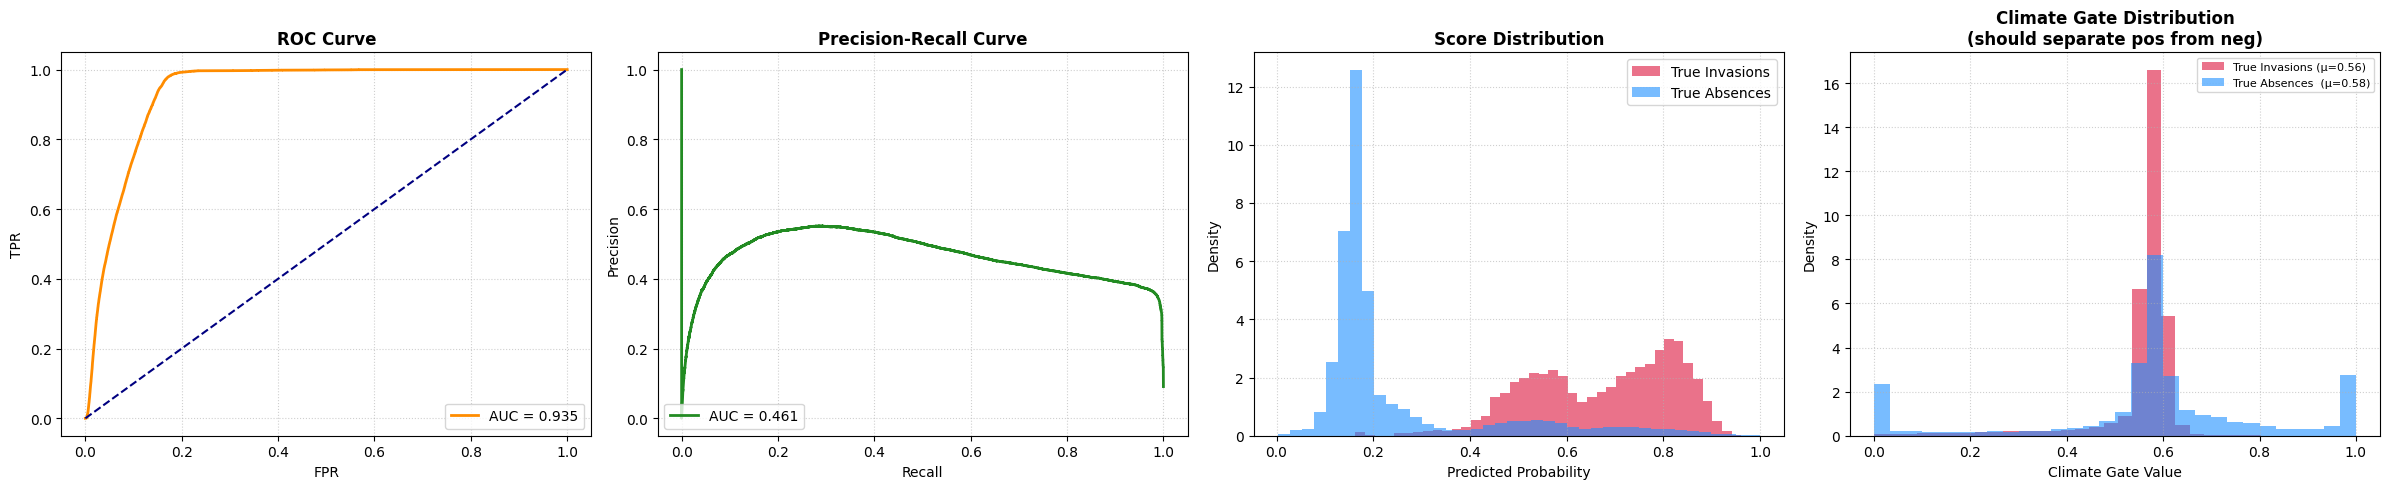

   📊 Saved to gnn_diagnostics_production_(edge-level_split).png

📊 GNN VERIFICATION REPORT — Country-holdout regime
   ROC-AUC : 0.9424  (Target > 0.80)
   PR-AUC  : 0.4824  (Target > 0.80)
   Pos mean: 0.5892 | Neg mean: 0.3233

🚦 Climate gate:
   True invasions : 0.461 ± 0.091
   True absences  : 0.293 ± 0.207
   Separation     : +0.168  ✅


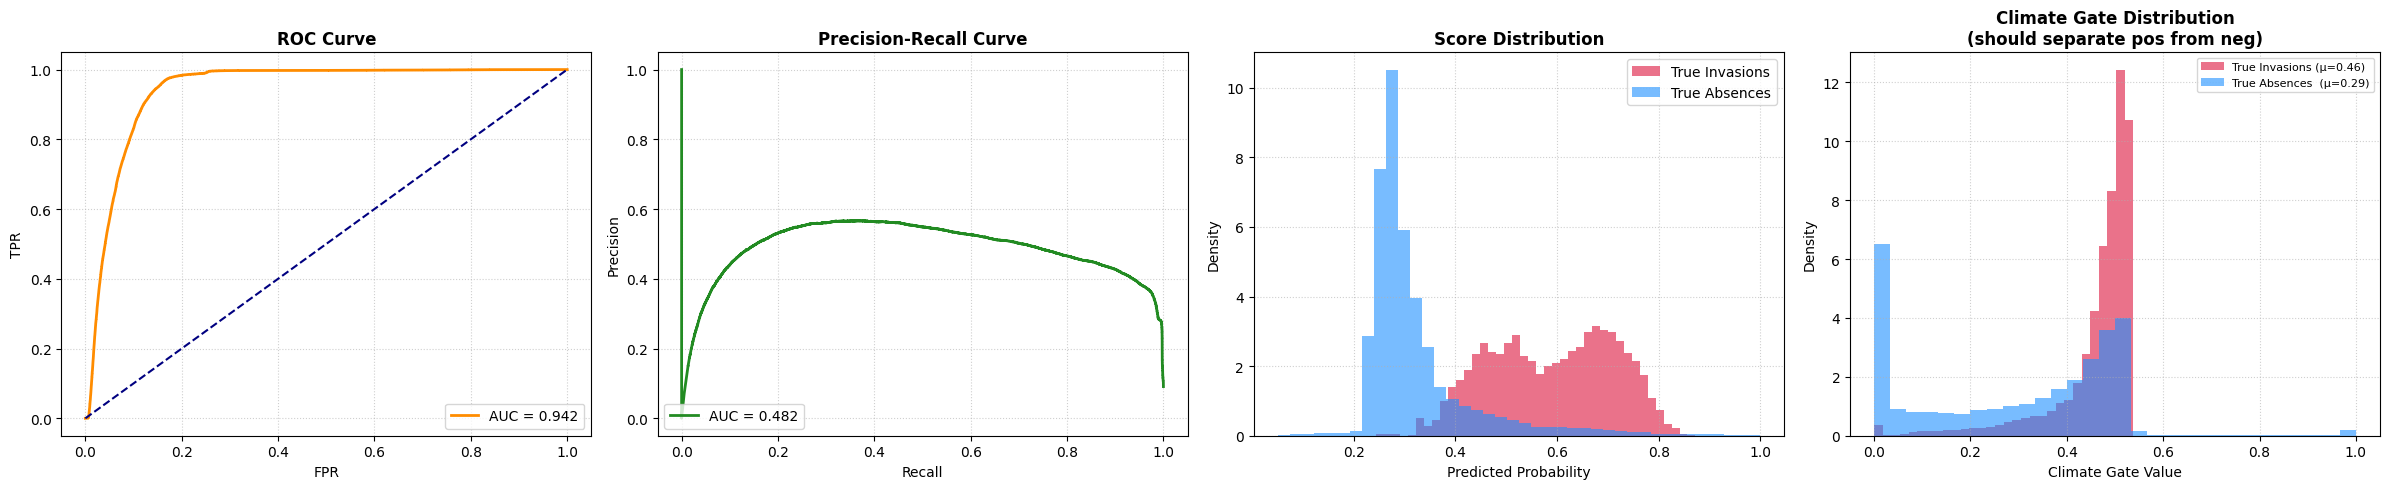

   📊 Saved to gnn_diagnostics_country-holdout_regime.png

Final ROC-AUC (production): 0.9354
Final PR-AUC  (production): 0.4606
Country-holdout ROC-AUC   : 0.9424
Country-holdout PR-AUC    : 0.4824


In [50]:
# ==============================================================================
# 14. EVALUATION DASHBOARD (4-panel)
# ==============================================================================
def plot_evaluation_dashboard(result, title_suffix=""):
    fpr, tpr           = result['fpr'], result['tpr']
    precision, recall  = result['precision'], result['recall']
    pos_probs, neg_probs = result['pos_probs'], result['neg_probs']
    pos_gate_np, neg_gate_np = result['pos_gate'], result['neg_gate']
    roc_auc_val, pr_auc_val  = result['roc_auc'], result['pr_auc']

    print("\n📊 GNN VERIFICATION REPORT" + (f" — {title_suffix}" if title_suffix else ""))
    print("=" * 60)
    print(f"   ROC-AUC : {roc_auc_val:.4f}  (Target > 0.80)")
    print(f"   PR-AUC  : {pr_auc_val:.4f}  (Target > 0.80)")
    print(f"   Pos mean: {pos_probs.mean():.4f} | Neg mean: {neg_probs.mean():.4f}")
    print("=" * 60)

    gate_sep = pos_gate_np.mean() - neg_gate_np.mean()
    marker = "✅" if gate_sep > 0.05 else ("⚠️ " if gate_sep > 0 else "❌")
    print(f"\n🚦 Climate gate:")
    print(f"   True invasions : {pos_gate_np.mean():.3f} ± {pos_gate_np.std():.3f}")
    print(f"   True absences  : {neg_gate_np.mean():.3f} ± {neg_gate_np.std():.3f}")
    print(f"   Separation     : {gate_sep:+.3f}  {marker}")

    fig, axes = plt.subplots(1, 4, figsize=(24, 5))

    axes[0].plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {roc_auc_val:.3f}')
    axes[0].plot([0,1],[0,1], 'navy', lw=1.5, linestyle='--')
    axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR')
    axes[0].set_title('ROC Curve', fontweight='bold')
    axes[0].legend(loc='lower right'); axes[0].grid(True, linestyle=':', alpha=0.6)

    axes[1].plot(recall, precision, color='forestgreen', lw=2, label=f'AUC = {pr_auc_val:.3f}')
    axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
    axes[1].set_title('Precision-Recall Curve', fontweight='bold')
    axes[1].legend(loc='lower left'); axes[1].grid(True, linestyle=':', alpha=0.6)

    axes[2].hist(pos_probs, bins=40, alpha=0.6, color='crimson',
                density=True, label='True Invasions')
    axes[2].hist(neg_probs, bins=40, alpha=0.6, color='dodgerblue',
                density=True, label='True Absences')
    axes[2].set_xlabel('Predicted Probability'); axes[2].set_ylabel('Density')
    axes[2].set_title('Score Distribution', fontweight='bold')
    axes[2].legend(); axes[2].grid(True, linestyle=':', alpha=0.6)

    axes[3].hist(pos_gate_np, bins=30, alpha=0.6, color='crimson',
                density=True, label=f'True Invasions (μ={pos_gate_np.mean():.2f})')
    axes[3].hist(neg_gate_np, bins=30, alpha=0.6, color='dodgerblue',
                density=True, label=f'True Absences  (μ={neg_gate_np.mean():.2f})')
    axes[3].set_xlabel('Climate Gate Value'); axes[3].set_ylabel('Density')
    axes[3].set_title('Climate Gate Distribution\n(should separate pos from neg)',
                      fontweight='bold')
    axes[3].legend(fontsize=8); axes[3].grid(True, linestyle=':', alpha=0.6)

    plt.tight_layout()
    fname = f"gnn_diagnostics{'_' + title_suffix.lower().replace(' ', '_') if title_suffix else ''}.png"
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"   📊 Saved to {fname}")


plot_evaluation_dashboard(final_result, title_suffix="Production (edge-level split)")
plot_evaluation_dashboard(country_holdout_result, title_suffix="Country-holdout regime")

print(f"\nFinal ROC-AUC (production): {final_result['roc_auc']:.4f}")
print(f"Final PR-AUC  (production): {final_result['pr_auc']:.4f}")
print(f"Country-holdout ROC-AUC   : {country_holdout_result['roc_auc']:.4f}")
print(f"Country-holdout PR-AUC    : {country_holdout_result['pr_auc']:.4f}")


In [51]:
# ==============================================================================
# 15. INFERENCE — HORIZON SCANNING
#
#    Scores all species not already recorded in a target country using the
#    production model. Species confirmed by GBIF but absent from SINAS are
#    NOT excluded — they represent potential unreported presences worth
#    flagging.
# ==============================================================================
INFERENCE_CHUNK = 2048

def execute_gnn_horizon_scan(target_country_name: str, top_n: int = 500) -> pd.DataFrame:
    if target_country_name not in co_to_idx:
        raise ValueError(f"'{target_country_name}' not found in spatial index.")

    encoder.eval(); predictor.eval(); country_ae.eval(); trade_encoder.eval()
    with torch.no_grad():
        co_lat = country_ae.encode(co_climate_tensor)
        sp_emb = encoder(sp_x_dict, train_edge_index_dict)['species']

    co_idx = co_to_idx[target_country_name]

    local_sp_ids      = df_sinas[df_sinas[country_col] == target_country_name]['gbif_id'].unique()
    local_sp_indices  = {sp_to_idx[s] for s in local_sp_ids if s in sp_to_idx}
    candidate_indices = [i for i in range(num_species) if i not in local_sp_indices]

    candidate_tensor = torch.tensor(candidate_indices, dtype=torch.long)
    country_tensor   = torch.full((len(candidate_indices),), co_idx, dtype=torch.long)

    scores = []
    with torch.no_grad():
        for i in range(0, len(candidate_indices), INFERENCE_CHUNK):
            chunk_sp  = candidate_tensor[i:i + INFERENCE_CHUNK]
            chunk_co  = country_tensor[i:i + INFERENCE_CHUNK]
            trade_lat = compute_trade_latent(chunk_sp, chunk_co,
                trade_channels_tensor, co_trade_import, presence_mat, trade_encoder)
            chunk_bio = biotic_opportunity_score(chunk_sp, chunk_co)
            chunk_logits, _ = predictor(
                sp_emb, co_lat, chunk_sp, chunk_co,
                sp_realized_mean, sp_realized_std,
                co_climate_tensor, trade_lat, bio_opp=chunk_bio)
            scores.append(torch.sigmoid(chunk_logits))

    probs = torch.cat(scores).numpy()

    df_scan = (
        pd.DataFrame([{
            'gbif_id':                  idx_to_sp[idx],
            'taxon_name':               id_to_name.get(idx_to_sp[idx], f"GBIF:{idx_to_sp[idx]}"),
            'gnn_invasion_probability': float(p),
        } for idx, p in zip(candidate_indices, probs)])
        .sort_values('gnn_invasion_probability', ascending=False)
        .reset_index(drop=True)
        .head(top_n)
    )
    print(f"✅ GNN scan complete — {len(df_scan)} candidates ranked.")
    return df_scan


In [52]:
# ==============================================================================
# 16. GBIF VALIDATION — DIRECT ID LOOKUP
# ==============================================================================
def validate_horizon_threats_gbif(
    risk_df: pd.DataFrame,
    gbif_country_code: str,
    species_to_validate: int = 100,
    sleep_time: float = 0.2
) -> pd.DataFrame:
    if not gbif_country_code:
        print("⚠️ No GBIF country code provided. Skipping validation.")
        return risk_df.head(species_to_validate)

    print(f"🔍 Validating via GBIF for country: '{gbif_country_code}'...")
    validated_records = []
    api_calls_made = 0; discarded_present = 0; errors_hit = 0

    with tqdm(total=species_to_validate, desc="Verified absent threats",
              unit="species") as pbar:
        for _, row in risk_df.iterrows():
            if len(validated_records) >= species_to_validate:
                print(f"\n🎯 Top {species_to_validate} verified threats secured.")
                break
            if api_calls_made > 0:
                time.sleep(sleep_time)
            api_calls_made += 1

            taxon_key    = int(row['gbif_id'])
            current_name = str(row['taxon_name'])
            try:
                if current_name.startswith("GBIF:"):
                    resolved_name = (gbif_species.name_usage(key=taxon_key)
                                     .get('scientificName', f"Unresolved ID: {taxon_key}"))
                else:
                    resolved_name = current_name

                occurrence_count = (occurrences.search(
                    taxonKey=taxon_key, country=gbif_country_code, limit=0)
                    .get('count', 0))

                if occurrence_count == 0:
                    new_row = row.to_dict()
                    new_row['taxon_name']            = resolved_name
                    new_row['gbif_matched_name']     = resolved_name
                    new_row['gbif_occurrence_count'] = occurrence_count
                    new_row['gbif_taxon_key']        = taxon_key
                    validated_records.append(new_row)
                    pbar.update(1)
                else:
                    discarded_present += 1

                pbar.set_postfix({'API': api_calls_made,
                                  'present': discarded_present,
                                  'errors': errors_hit})
            except Exception as e:
                errors_hit += 1
                time.sleep(sleep_time * 5)
                err_row = row.to_dict()
                err_row['gbif_matched_name']     = f"FETCH ERROR: {str(e)[:40]}"
                err_row['gbif_occurrence_count'] = -1
                err_row['gbif_taxon_key']        = taxon_key
                validated_records.append(err_row)
                pbar.update(1)

    return pd.DataFrame(validated_records).reset_index(drop=True)


In [53]:
# ==============================================================================
# RUN — BELGIUM
# ==============================================================================
belgium_gnn_rankings = execute_gnn_horizon_scan('Belgium', top_n=500)

belgium_validated = validate_horizon_threats_gbif(
    belgium_gnn_rankings,
    gbif_country_code='BE',
    species_to_validate=100,
    sleep_time=1
)

belgium_validated.head(20)

RuntimeError: Expected all tensors to be on the same device, but found at least two devices, cuda:0 and cpu! (when checking argument for argument mat1 in method wrapper_CUDA_addmm)

In [54]:
#static model import example

import torch
import pandas as pd

# ==============================================================================
# A. PASTE YOUR MODEL CLASS DEFINITIONS HERE (STATIC LOAD)
# You only need: NicheMatchingPredictor and TradePathwayEncoder
# (CountryAutoencoder and RelationalEcologicalGNN are no longer needed!)
# ==============================================================================

def load_static_scanner(checkpoint_path: str):
    """Loads the precomputed static tensors and model weights."""
    print("⏳ Loading static horizon scanner...")
    ckpt = torch.load(checkpoint_path, map_location='cpu', weights_only=False)

    # Re-instantiate the predictors
    emb_dim = ckpt['sp_emb'].shape[1]
    co_latent_dim = ckpt['co_lat'].shape[1]
    n_co_features = ckpt['co_climate_tensor'].shape[1]
    trade_latent_dim = 16 # Based on your script
    num_channels = ckpt['trade_channels_tensor'].shape[0]

    predictor = NicheMatchingPredictor(
        sp_dim=emb_dim, co_latent_dim=co_latent_dim,
        n_co_features=n_co_features, trade_latent_dim=trade_latent_dim
    )
    trade_encoder = TradePathwayEncoder(
        num_channels=num_channels, latent_dim=trade_latent_dim, hidden_dim=32
    )

    predictor.load_state_dict(ckpt['predictor_state'])
    trade_encoder.load_state_dict(ckpt['trade_encoder_state'])

    predictor.eval()
    trade_encoder.eval()

    print("✅ Scanner ready.")
    return predictor, trade_encoder, ckpt

def execute_rapid_scan(target_country: str, top_n: int, scanner_data: tuple):
    """Rapid horizon scanning using static tensors."""
    predictor, trade_encoder, ckpt = scanner_data

    if target_country not in ckpt['co_to_idx']:
        raise ValueError(f"'{target_country}' not found in spatial index.")

    co_idx_val = ckpt['co_to_idx'][target_country]

    # We score ALL species in the index
    candidate_indices = list(range(ckpt['num_species']))
    candidate_tensor = torch.tensor(candidate_indices, dtype=torch.long)
    country_tensor = torch.full((len(candidate_indices),), co_idx_val, dtype=torch.long)

    scores = []
    chunk_size = 2048

    with torch.no_grad():
        for i in range(0, len(candidate_indices), chunk_size):
            chunk_sp = candidate_tensor[i:i + chunk_size]
            chunk_co = country_tensor[i:i + chunk_size]

            # Dynamic trade routing and biotic opp rely purely on fast tensor math now
            device = chunk_sp.device
            trade_to_dest = ckpt['trade_channels_tensor'][:, :, co_idx_val].permute(1, 0).unsqueeze(0)
            trade_to_dest = trade_to_dest.expand(len(chunk_sp), -1, -1).permute(0, 2, 1)

            native_mask = ckpt['presence_mat'][chunk_sp].unsqueeze(1)
            export_vec = (trade_to_dest * native_mask).sum(dim=2) / native_mask.sum(dim=2).clamp(min=1)
            import_vec = ckpt['co_trade_import'][chunk_co]
            trade_lat = trade_encoder(import_vec, export_vec)

            # Note: Biotic opportunity (bio_opp_mat) is omitted here for brevity,
            # ensure you save/load 'bio_opp_mat' in your export_dict if it's critical.

            chunk_logits, _ = predictor(
                sp_emb=ckpt['sp_emb'],
                co_latent=ckpt['co_lat'],
                sp_idx=chunk_sp,
                co_idx=chunk_co,
                sp_realized_mean=ckpt['sp_realized_mean'],
                sp_realized_std=ckpt['sp_realized_std'],
                co_climate_tensor=ckpt['co_climate_tensor'],
                trade_latent=trade_lat
            )
            scores.append(torch.sigmoid(chunk_logits))

    probs = torch.cat(scores).numpy()

    # Format Results
    results = []
    for idx, p in zip(candidate_indices, probs):
        results.append({
            'gbif_id': ckpt['idx_to_sp'][idx],
            'taxon_name': ckpt['id_to_name'].get(ckpt['idx_to_sp'][idx], f"Unknown ID: {idx}"),
            'invasion_probability': float(p)
        })

    df_scan = pd.DataFrame(results).sort_values('invasion_probability', ascending=False).head(top_n)
    return df_scan

# ==============================================================================
# RUN INFERENCE
# ==============================================================================
scanner_data = load_static_scanner('horizon_scanner_static.pt')
risk_df = execute_rapid_scan('Australia', top_n=50, scanner_data=scanner_data)
print(risk_df)

⏳ Loading static horizon scanner...


FileNotFoundError: [Errno 2] No such file or directory: 'horizon_scanner_static.pt'